# Lockbench Analysis — ARM (Apple M3 Pro) vs x86 (Intel Xeon E5-2650L v3)

Comprehensive analysis of synchronization primitive performance across two platforms.
Data: `combined_lockbench.csv` (French CSV: `;` delimiter, `,` decimal separator).

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.lines import Line2D

plt.rcParams.update({'font.size': 11, 'figure.dpi': 150,
                      'axes.spines.top': False, 'axes.spines.right': False})

df = pd.read_csv('combined_lockbench.csv', sep=';', decimal=',')
df['ops_m'] = df['ops_s'] / 1e6

# IMPORTANT: separate the cs_work sweep from the base mutex workload
mutex = df[(df['workload'] == 'mutex') & (df['cs_work'] == 0)].copy()
cs_sweep = df[(df['workload'] == 'mutex') & (df['cs_work'] >= 0) &
              (df['lock'] == 'ttas') & (df['threads'] == 4)].copy()
rw_data = df[df['workload'] == 'rw'].copy()
rcu_data = df[df['workload'] == 'rcu'].copy()

print(f"Total: {len(df)} rows")
print(f"  Mutex (cs_work=0): {len(mutex)} rows")
print(f"  CS sweep (ttas 4T): {len(cs_sweep)} rows")
print(f"  RW workloads: {len(rw_data)} rows")
print(f"  RCU: {len(rcu_data)} rows")

Total: 500 rows
  Mutex (cs_work=0): 250 rows
  CS sweep (ttas 4T): 70 rows
  RW workloads: 160 rows
  RCU: 40 rows


In [29]:
# Constants and helpers
LOCK_ORDER = ['tas', 'ttas', 'cas', 'ticket', 'rw', 'occ']
LOCK_LABELS = {'tas': 'TAS', 'ttas': 'TTAS', 'cas': 'CAS',
               'ticket': 'Ticket', 'rw': 'RW', 'occ': 'OCC', 'rcu': 'RCU'}
LOCK_COLORS = {'tas': '#d62728', 'ttas': '#1f77b4', 'cas': '#2ca02c',
               'ticket': '#9467bd', 'rw': '#ff7f0e', 'occ': '#8c564b', 'rcu': '#17becf'}
LOCK_MARKERS = {'tas': 'o', 'ttas': 's', 'cas': '^', 'ticket': 'D',
                'rw': 'v', 'occ': 'P', 'rcu': 'X'}
PLAT_NAMES = {'arm': 'Apple M3 Pro (ARM)', 'intel': 'Xeon E5-2650L v3 (x86)'}
PLAT_SHORT = {'arm': 'ARM', 'intel': 'x86'}

def agg(data, group_cols):
    return data.groupby(group_cols).agg(
        ops_m_mean=('ops_m', 'mean'),
        ops_m_std=('ops_m', 'std'),
        ops_m_cv=('ops_m', lambda x: x.std()/x.mean()*100 if x.mean()>0 else 0),
        fairness_mean=('fairness_ratio', 'mean'),
        fairness_std=('fairness_ratio', 'std'),
        count=('ops_m', 'count')
    ).reset_index()

---
## 1. Throughput Scaling — Mutex Workload

How does each lock's throughput scale with thread count under pure exclusive access?

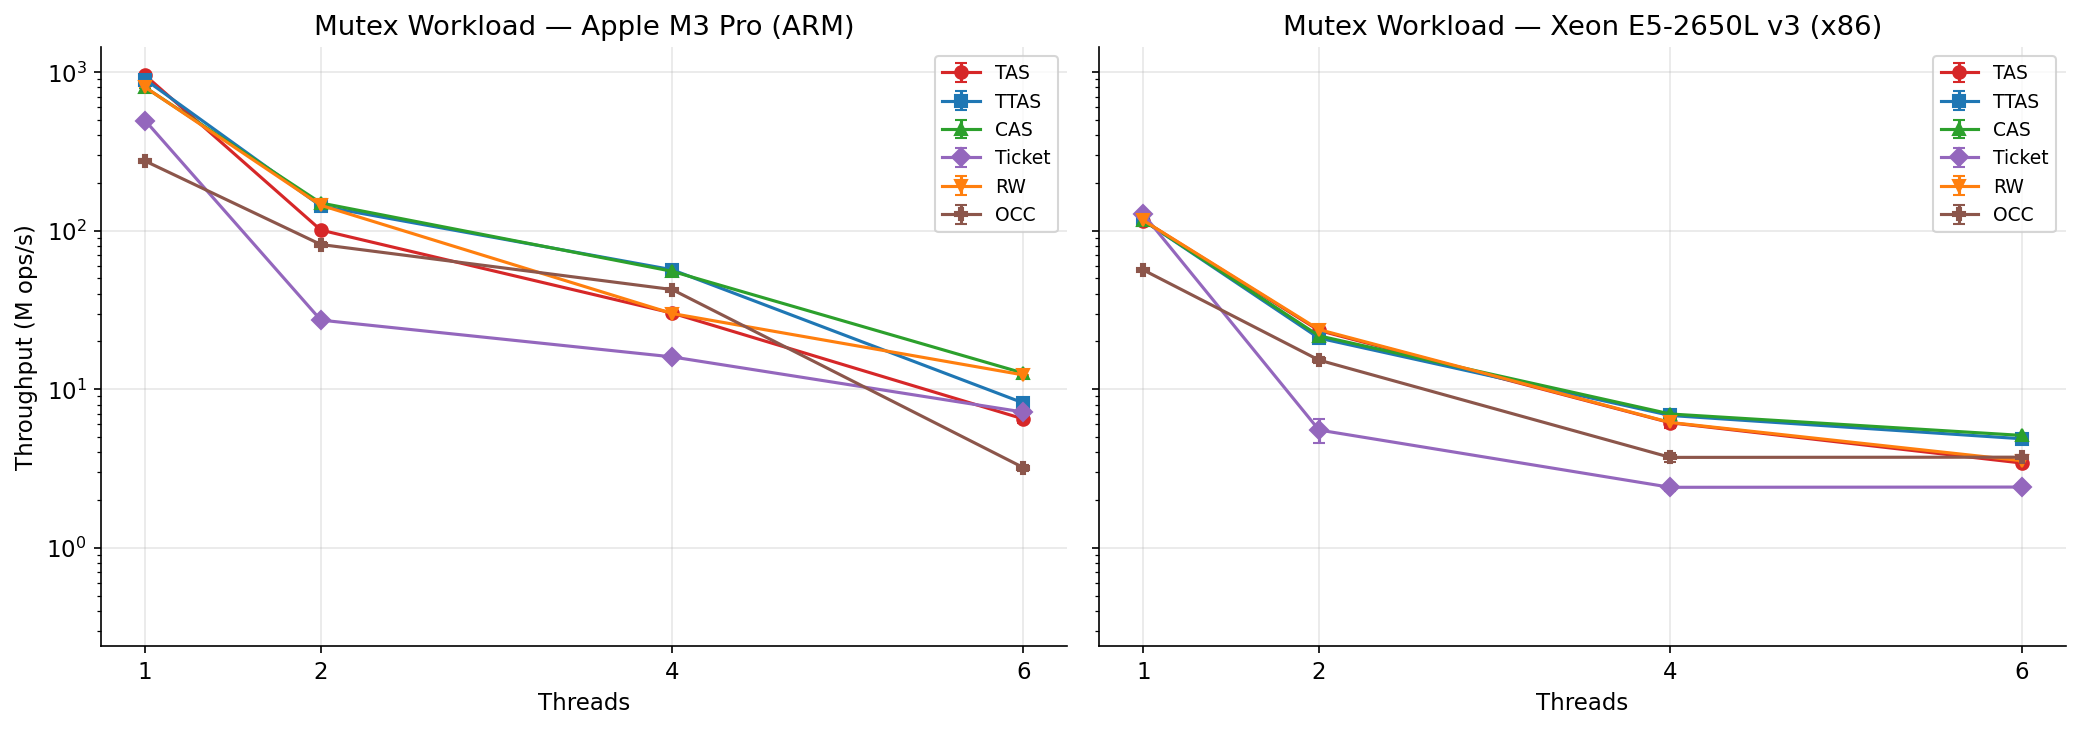

In [30]:
g = agg(mutex, ['platform', 'lock', 'threads'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, plat in zip(axes, ['arm', 'intel']):
    sub = g[g['platform'] == plat]
    for lock in LOCK_ORDER:
        d = sub[sub['lock'] == lock].sort_values('threads')
        if d.empty: continue
        ax.errorbar(d['threads'], d['ops_m_mean'], yerr=d['ops_m_std'],
                    label=LOCK_LABELS[lock], color=LOCK_COLORS[lock],
                    marker=LOCK_MARKERS[lock], capsize=3, linewidth=1.5)
    ax.set_yscale('log')
    ax.set_xlabel('Threads')
    ax.set_title(f'Mutex Workload \u2014 {PLAT_NAMES[plat]}')
    ax.legend(fontsize=9)
    ax.set_xticks(sorted(sub['threads'].unique()))
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Throughput (M ops/s)')
fig.tight_layout()
fig.savefig('plot1_throughput_scaling.png', bbox_inches='tight')
plt.show()

---
## 2. Contention Cost — Scalability Efficiency

Scalability efficiency = throughput(N threads) / throughput(1 thread). Values < 1 show contention overhead.  
Ideal (no contention) would be 1.0 (since the shared counter is a serial bottleneck, not a parallelizable workload).

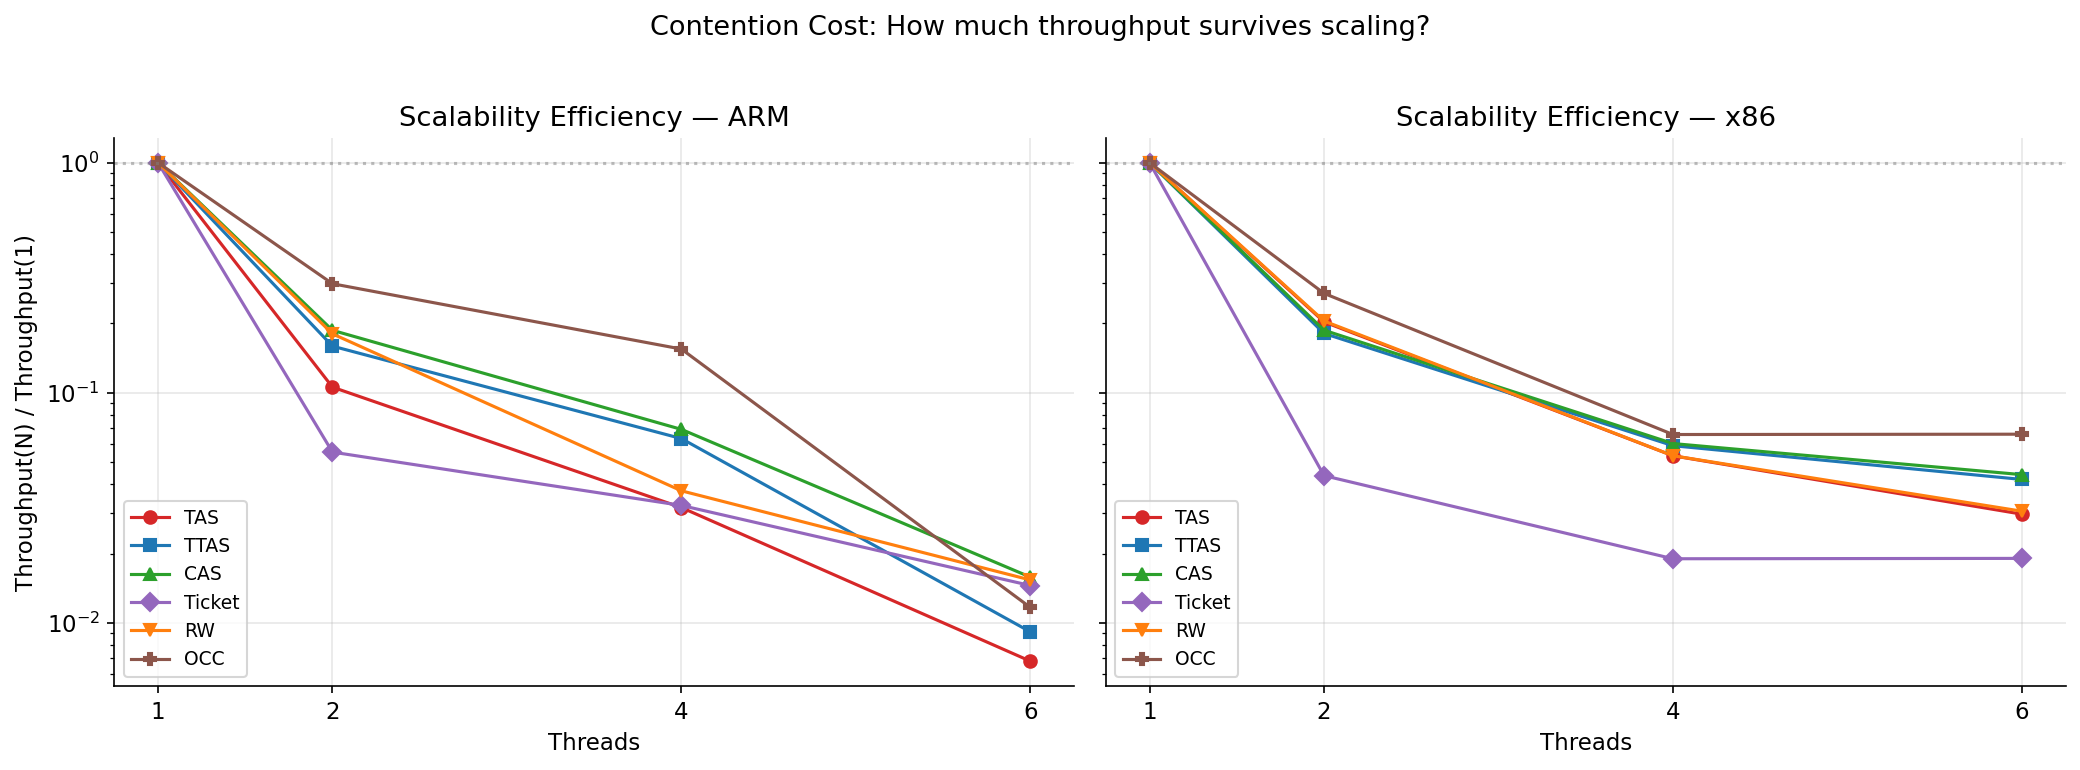

Efficiency at 6 threads (throughput retained vs 1T):
   ARM    TAS: 0.0068  (147x contention penalty)
   ARM   TTAS: 0.0091  (109x contention penalty)
   ARM    OCC: 0.0117  (86x contention penalty)
   ARM Ticket: 0.0145  (69x contention penalty)
   ARM     RW: 0.0154  (65x contention penalty)
   ARM    CAS: 0.0158  (63x contention penalty)
   x86 Ticket: 0.0191  (52x contention penalty)
   x86    TAS: 0.0297  (34x contention penalty)
   x86     RW: 0.0306  (33x contention penalty)
   x86   TTAS: 0.0420  (24x contention penalty)
   x86    CAS: 0.0440  (23x contention penalty)
   x86    OCC: 0.0660  (15x contention penalty)


In [31]:
g_eff = agg(mutex, ['platform', 'lock', 'threads'])
# Get 1T baseline
base = g_eff[g_eff['threads']==1][['platform','lock','ops_m_mean']].rename(
    columns={'ops_m_mean': 'base_ops'})
g_eff = g_eff.merge(base, on=['platform','lock'])
g_eff['efficiency'] = g_eff['ops_m_mean'] / g_eff['base_ops']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, plat in zip(axes, ['arm', 'intel']):
    sub = g_eff[g_eff['platform']==plat]
    for lock in LOCK_ORDER:
        d = sub[sub['lock']==lock].sort_values('threads')
        if d.empty: continue
        ax.plot(d['threads'], d['efficiency'],
                label=LOCK_LABELS[lock], color=LOCK_COLORS[lock],
                marker=LOCK_MARKERS[lock], linewidth=1.5)
    ax.set_xlabel('Threads')
    ax.set_title(f'Scalability Efficiency \u2014 {PLAT_SHORT[plat]}')
    ax.set_yscale('log')
    ax.set_xticks(sorted(sub['threads'].unique()))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)
axes[0].set_ylabel('Throughput(N) / Throughput(1)')
fig.suptitle('Contention Cost: How much throughput survives scaling?', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig('plot7_scalability_efficiency.png', bbox_inches='tight')
plt.show()

# Print the worst offenders
worst = g_eff[g_eff['threads']==6][['platform','lock','efficiency']].sort_values('efficiency')
print("Efficiency at 6 threads (throughput retained vs 1T):")
for _, r in worst.iterrows():
    print(f"  {PLAT_SHORT[r['platform']]:>4s} {LOCK_LABELS[r['lock']]:>6s}: {r['efficiency']:.4f}  ({1/r['efficiency']:.0f}x contention penalty)")

---
## 3. Fairness vs Throughput Tradeoff

The fundamental lock design tradeoff: fair locks (Ticket) sacrifice throughput for equal scheduling;  
unfair locks (TAS, TTAS, CAS) let the cache-line holder win repeatedly, boosting throughput but starving others.

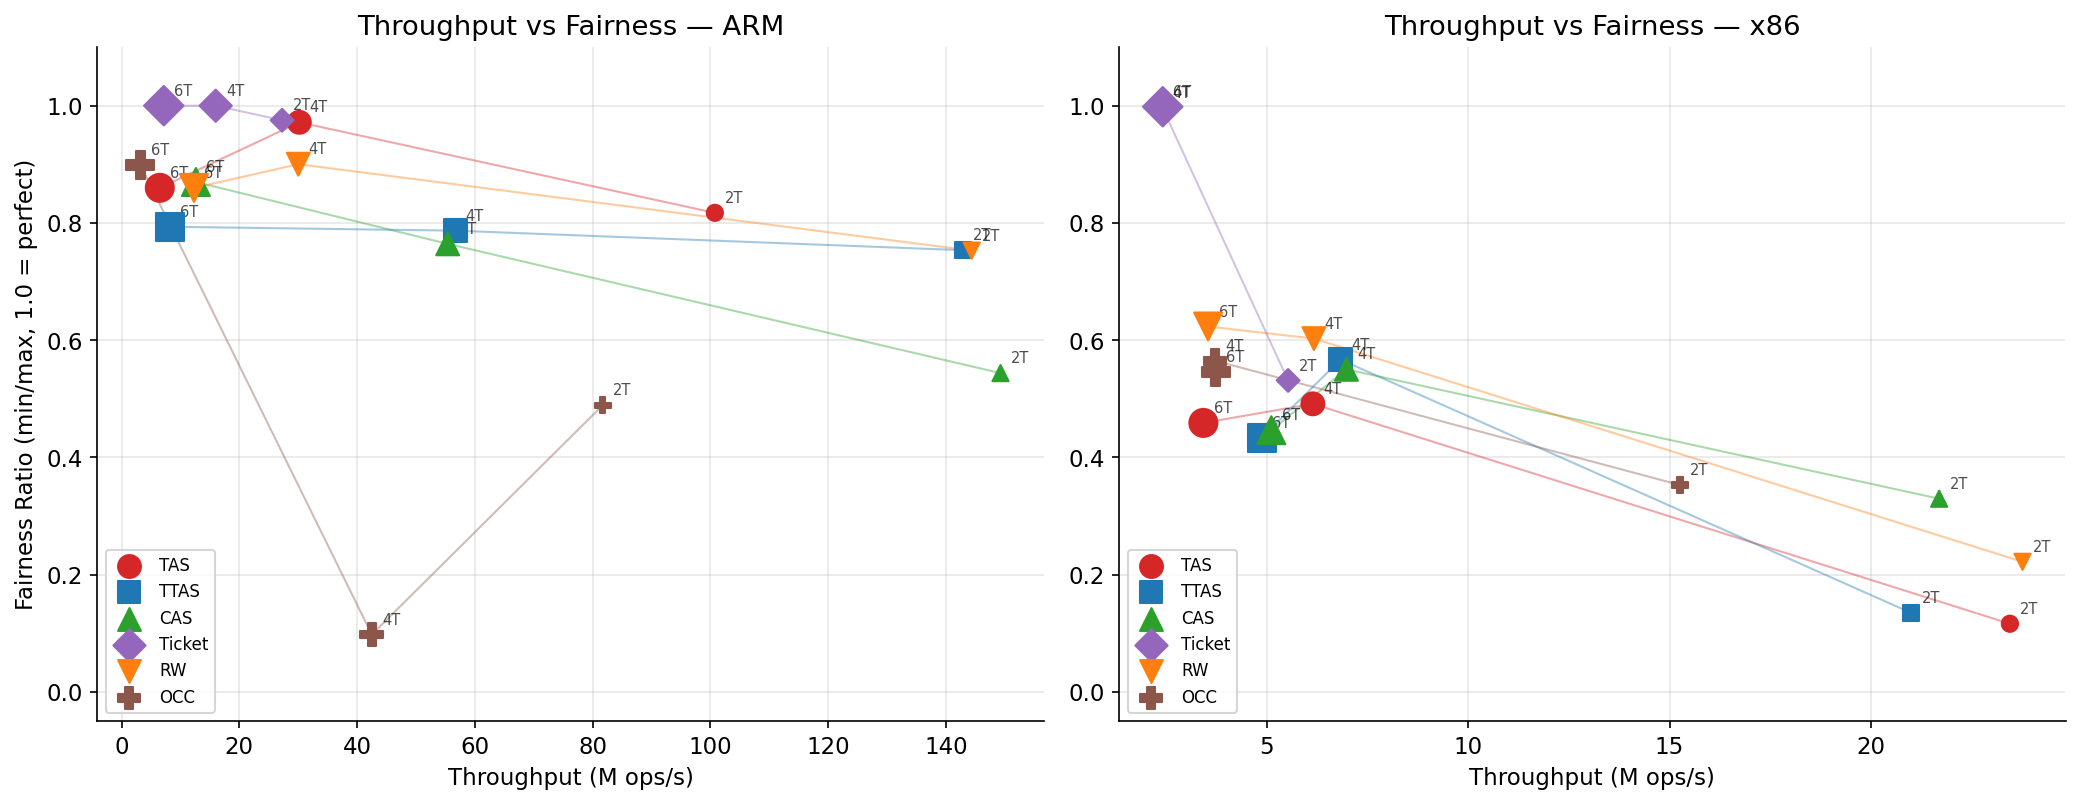

In [32]:
mutex_mt = mutex[mutex['threads'] > 1]
g2 = agg(mutex_mt, ['platform', 'lock', 'threads'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, plat in zip(axes, ['arm', 'intel']):
    sub = g2[g2['platform'] == plat]
    for lock in LOCK_ORDER:
        d = sub[sub['lock'] == lock].sort_values('threads')
        if d.empty: continue
        sizes = d['threads'] * 30
        ax.scatter(d['ops_m_mean'], d['fairness_mean'],
                   label=LOCK_LABELS[lock], color=LOCK_COLORS[lock],
                   marker=LOCK_MARKERS[lock], s=sizes, zorder=5)
        ax.plot(d['ops_m_mean'], d['fairness_mean'],
                color=LOCK_COLORS[lock], alpha=0.4, linewidth=1)
        # Annotate thread counts
        for _, row in d.iterrows():
            ax.annotate(f"{int(row['threads'])}T", (row['ops_m_mean'], row['fairness_mean']),
                       textcoords='offset points', xytext=(5, 5), fontsize=7, alpha=0.7)
    ax.set_xlabel('Throughput (M ops/s)')
    ax.set_title(f'Throughput vs Fairness \u2014 {PLAT_SHORT[plat]}')
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.1)
axes[0].set_ylabel('Fairness Ratio (min/max, 1.0 = perfect)')
fig.tight_layout()
fig.savefig('plot2_fairness_vs_throughput.png', bbox_inches='tight')
plt.show()

---
## 4. Fairness Heatmap

Detailed view of fairness across all lock/thread combinations. Values near 1.0 = fair, near 0 = severe starvation.

/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_24752/1252731870.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


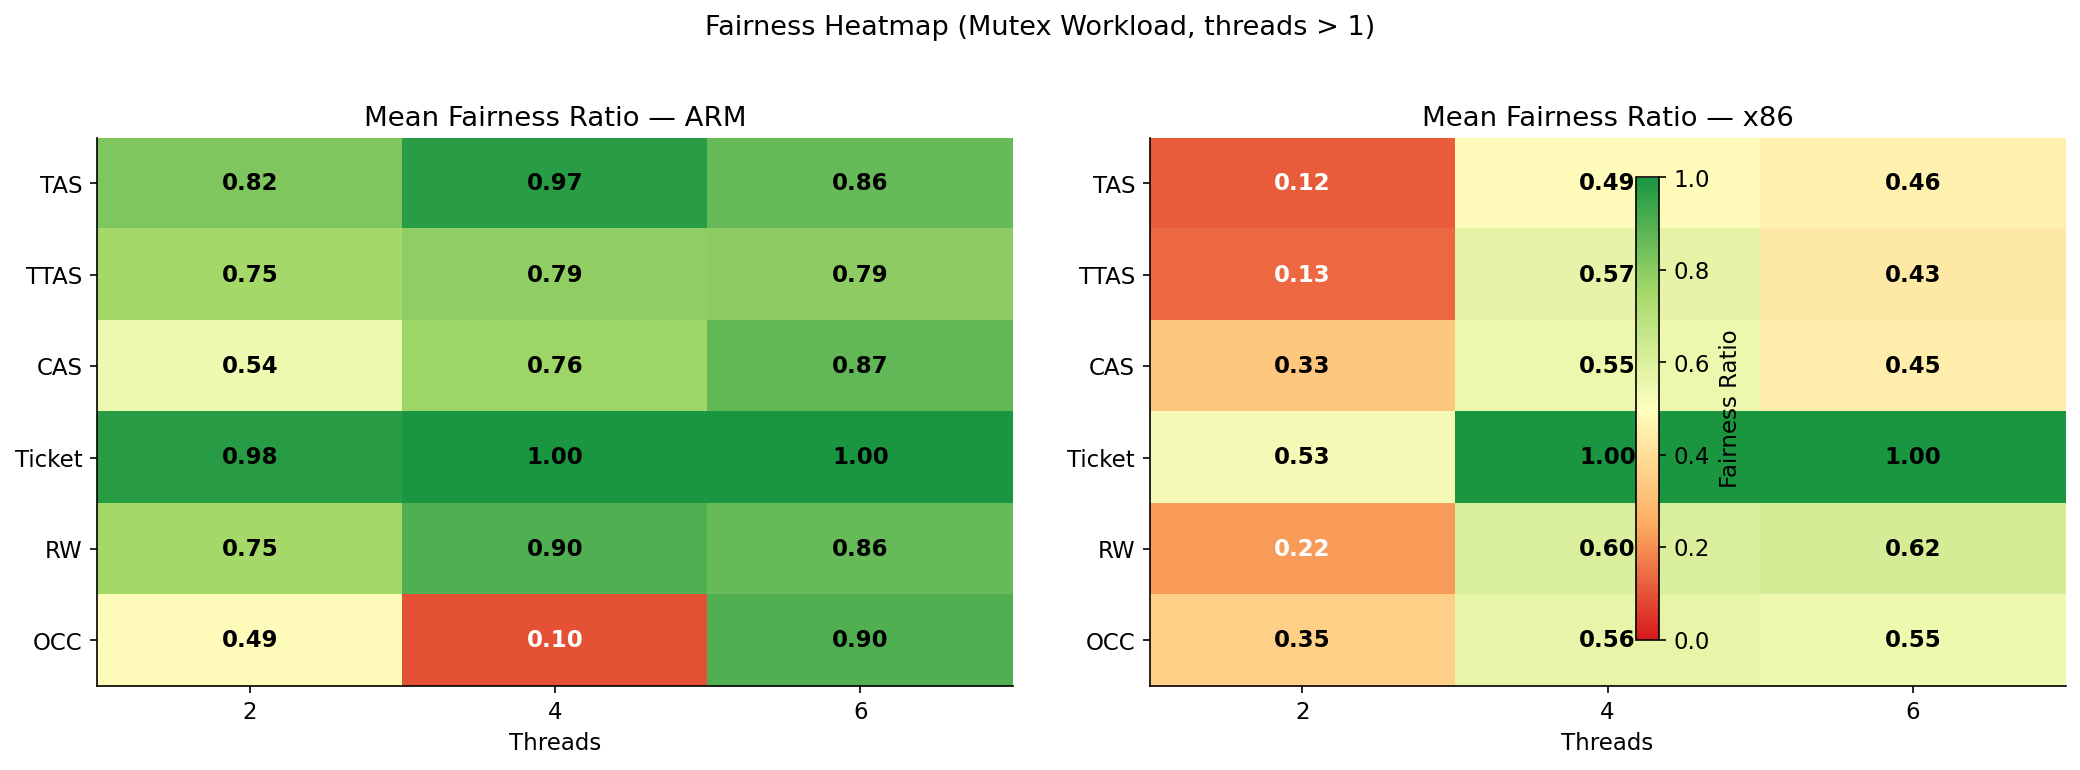

In [33]:
fair_g = mutex[mutex['threads']>1].groupby(['platform','lock','threads'])['fairness_ratio'].mean().reset_index()

cmap_fair = mcolors.LinearSegmentedColormap.from_list('fair',
    ['#d7191c', '#fdae61', '#ffffbf', '#a6d96a', '#1a9641'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, plat in zip(axes, ['arm', 'intel']):
    sub = fair_g[fair_g['platform']==plat]
    pivot = sub.pivot(index='lock', columns='threads', values='fairness_ratio')
    pivot = pivot.reindex(LOCK_ORDER)
    pivot.index = [LOCK_LABELS.get(l,l) for l in pivot.index]

    im = ax.imshow(pivot.values, cmap=cmap_fair, vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('Threads')
    ax.set_title(f'Mean Fairness Ratio \u2014 {PLAT_SHORT[plat]}')

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontweight='bold', fontsize=11,
                        color='white' if val < 0.3 else 'black')

fig.colorbar(im, ax=axes, label='Fairness Ratio', shrink=0.8)
fig.suptitle('Fairness Heatmap (Mutex Workload, threads > 1)', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig('plot8_fairness_heatmap.png', bbox_inches='tight')
plt.show()

---
## 5. OCC Deep-Dive: Livelock Pathology

OCC (Optimistic Concurrency Control) shows unique behavior under exclusive workloads:  
- **Starvation at 4T**: One thread monopolizes while others livelock (fairness ~0.03-0.20 on ARM)  
- **13x throughput cliff at 6T on ARM**: E-cores break the monopoly, everyone contends equally  
- **Intel OCC 4T \u2248 6T**: Contention already saturated, more threads can't make it worse  
- **ARM/Intel crossover**: ARM loses to Intel at 6T (0.86x) — E-cores are a liability

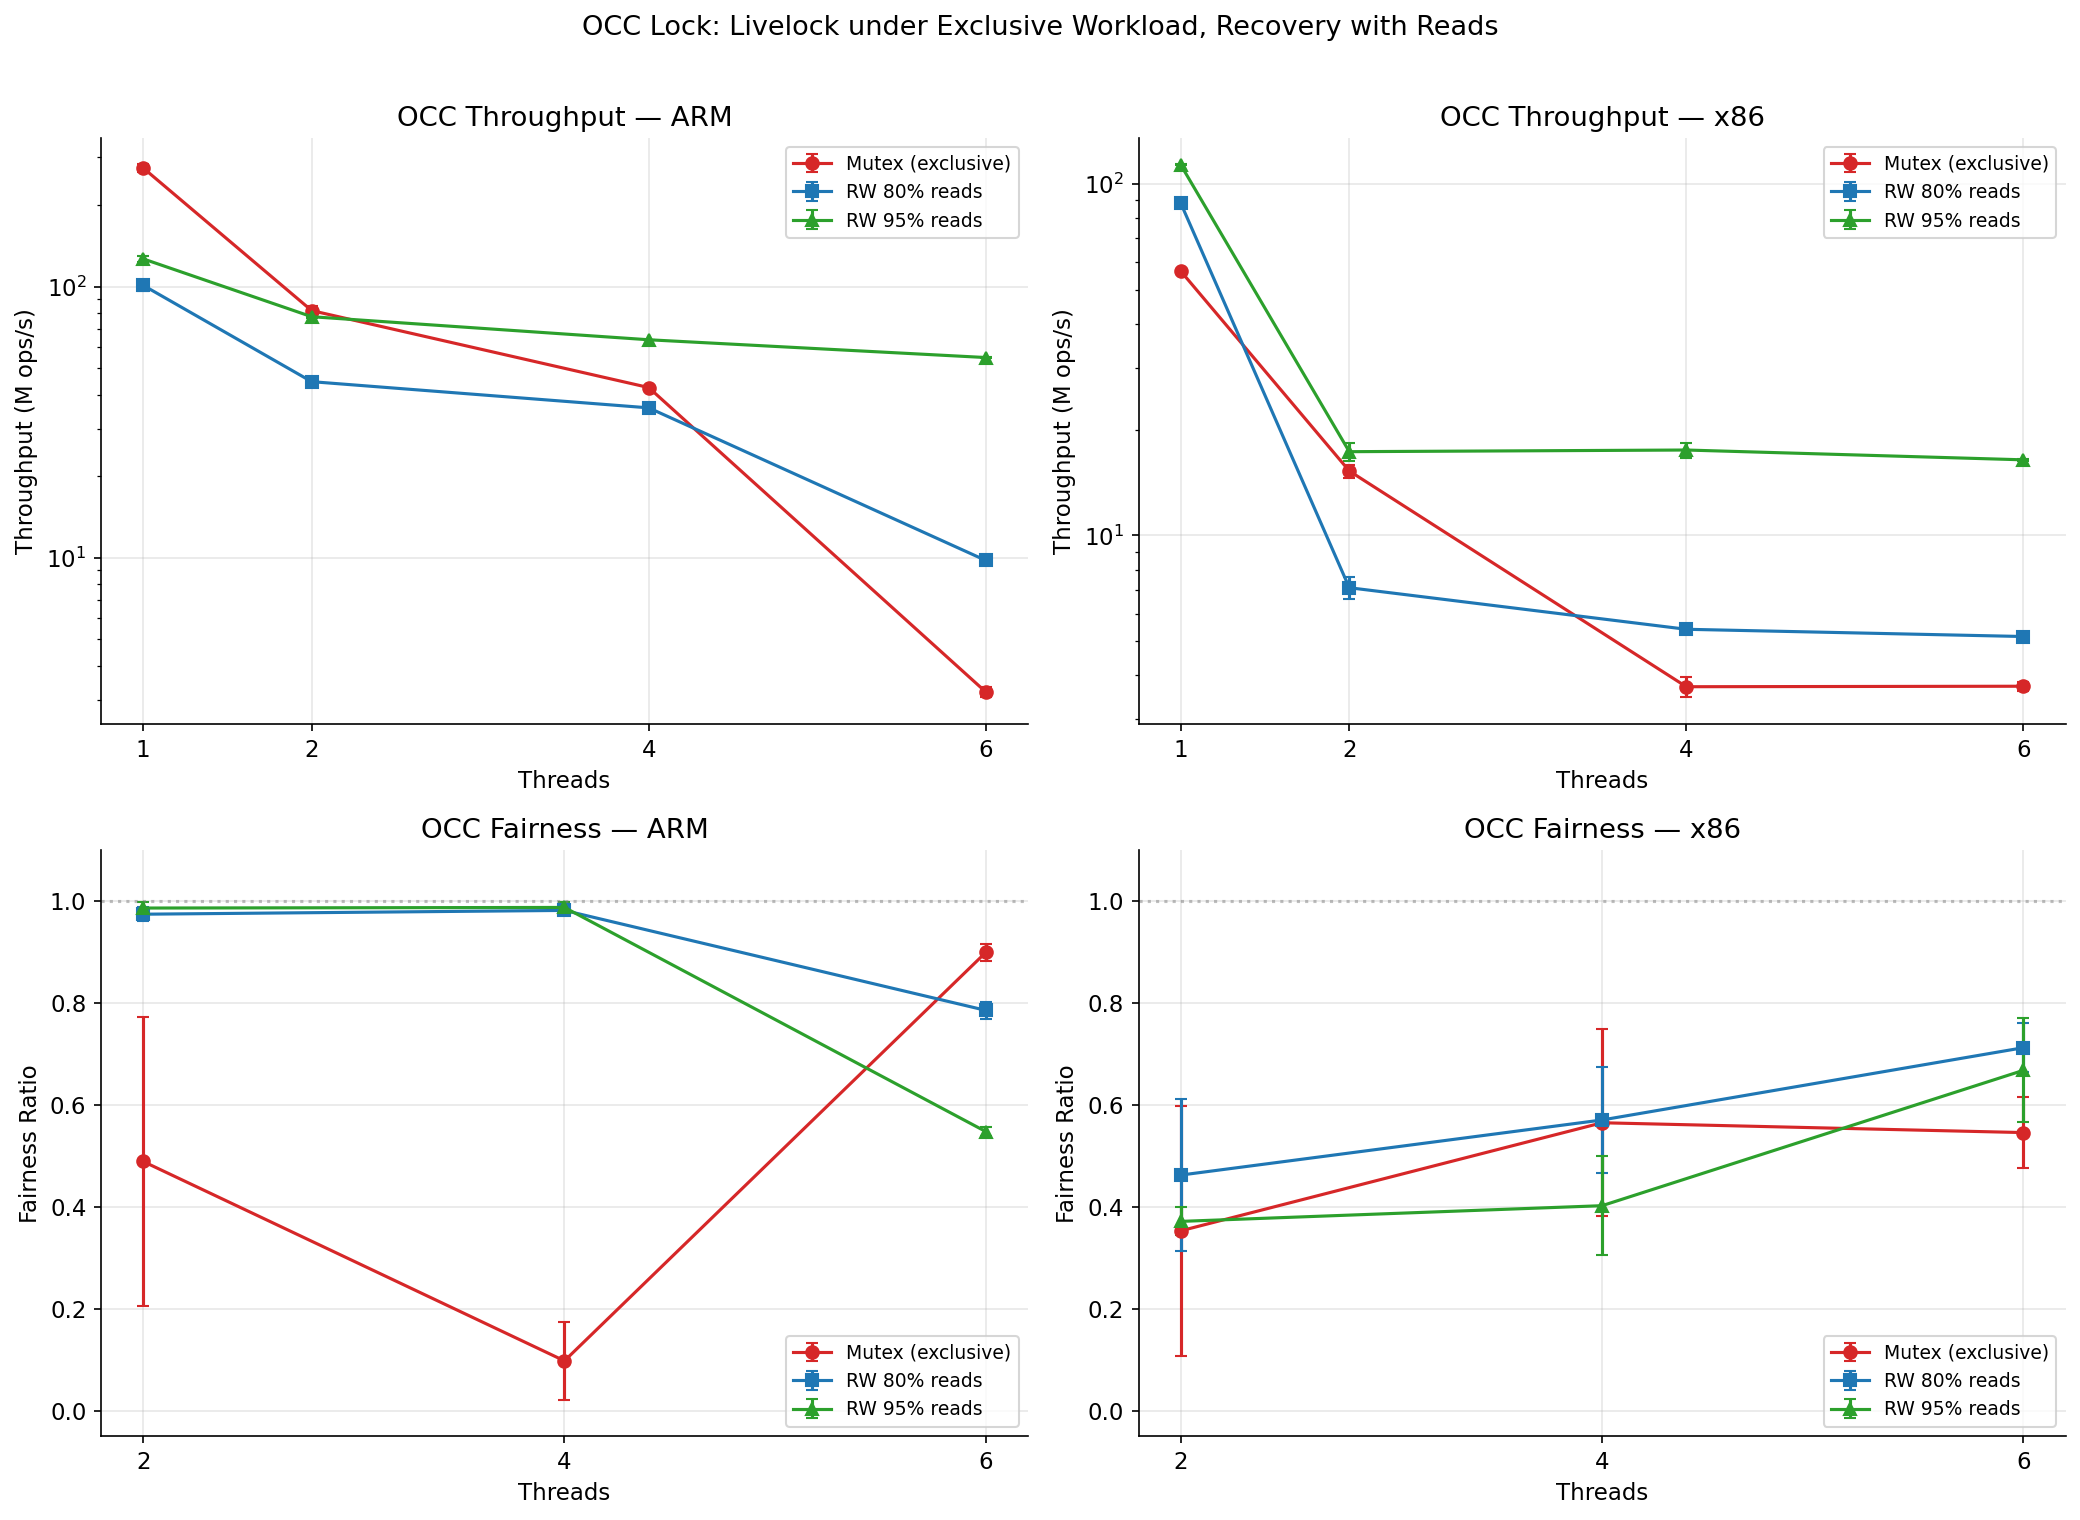


Key OCC observations:
  ARM mutex 4T: 42.5 M ops/s, fairness=0.098
  ARM mutex 6T: 3.2 M ops/s, fairness=0.899
  4T->6T cliff: 13.3x drop
  Intel mutex 6T: 3.7 M ops/s (beats ARM!)


In [34]:
occ_all = df[df['lock']=='occ'].copy()
occ_all['wl_label'] = occ_all.apply(
    lambda r: 'Mutex (exclusive)' if r['workload']=='mutex'
              else f"RW {int(r['read_pct'])}% reads", axis=1)

g_occ = occ_all.groupby(['platform','wl_label','threads']).agg(
    ops_m_mean=('ops_m','mean'), ops_m_std=('ops_m','std'),
    fair_mean=('fairness_ratio','mean'), fair_std=('fairness_ratio','std')
).reset_index()

WL_COLORS = {'Mutex (exclusive)': '#d62728', 'RW 80% reads': '#1f77b4', 'RW 95% reads': '#2ca02c'}
WL_MARKERS = {'Mutex (exclusive)': 'o', 'RW 80% reads': 's', 'RW 95% reads': '^'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row: throughput
for col, plat in enumerate(['arm', 'intel']):
    ax = axes[0][col]
    sub = g_occ[g_occ['platform']==plat]
    for wl in ['Mutex (exclusive)', 'RW 80% reads', 'RW 95% reads']:
        d = sub[sub['wl_label']==wl].sort_values('threads')
        if d.empty: continue
        ax.errorbar(d['threads'], d['ops_m_mean'], yerr=d['ops_m_std'],
                    label=wl, color=WL_COLORS[wl], marker=WL_MARKERS[wl],
                    capsize=3, linewidth=1.5)
    ax.set_yscale('log')
    ax.set_xlabel('Threads')
    ax.set_ylabel('Throughput (M ops/s)')
    ax.set_title(f'OCC Throughput \u2014 {PLAT_SHORT[plat]}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([1,2,4,6])

# Bottom row: fairness
for col, plat in enumerate(['arm', 'intel']):
    ax = axes[1][col]
    sub = g_occ[(g_occ['platform']==plat) & (g_occ['threads']>1)]
    for wl in ['Mutex (exclusive)', 'RW 80% reads', 'RW 95% reads']:
        d = sub[sub['wl_label']==wl].sort_values('threads')
        if d.empty: continue
        ax.errorbar(d['threads'], d['fair_mean'], yerr=d['fair_std'],
                    label=wl, color=WL_COLORS[wl], marker=WL_MARKERS[wl],
                    capsize=3, linewidth=1.5)
    ax.set_xlabel('Threads')
    ax.set_ylabel('Fairness Ratio')
    ax.set_title(f'OCC Fairness \u2014 {PLAT_SHORT[plat]}')
    ax.set_ylim(-0.05, 1.1)
    ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.5)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([2,4,6])

fig.suptitle('OCC Lock: Livelock under Exclusive Workload, Recovery with Reads', fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig('plot9_occ_deep_dive.png', bbox_inches='tight')
plt.show()

print("\nKey OCC observations:")
arm4 = g_occ[(g_occ['platform']=='arm')&(g_occ['wl_label']=='Mutex (exclusive)')&(g_occ['threads']==4)]
arm6 = g_occ[(g_occ['platform']=='arm')&(g_occ['wl_label']=='Mutex (exclusive)')&(g_occ['threads']==6)]
int6 = g_occ[(g_occ['platform']=='intel')&(g_occ['wl_label']=='Mutex (exclusive)')&(g_occ['threads']==6)]
print(f"  ARM mutex 4T: {arm4['ops_m_mean'].values[0]:.1f} M ops/s, fairness={arm4['fair_mean'].values[0]:.3f}")
print(f"  ARM mutex 6T: {arm6['ops_m_mean'].values[0]:.1f} M ops/s, fairness={arm6['fair_mean'].values[0]:.3f}")
print(f"  4T->6T cliff: {arm4['ops_m_mean'].values[0]/arm6['ops_m_mean'].values[0]:.1f}x drop")
print(f"  Intel mutex 6T: {int6['ops_m_mean'].values[0]:.1f} M ops/s (beats ARM!)")

---
## 6. Read-Optimized Locks: RW vs OCC vs RCU

Compare how reader-writer locks, OCC, and RCU perform under read-heavy workloads.

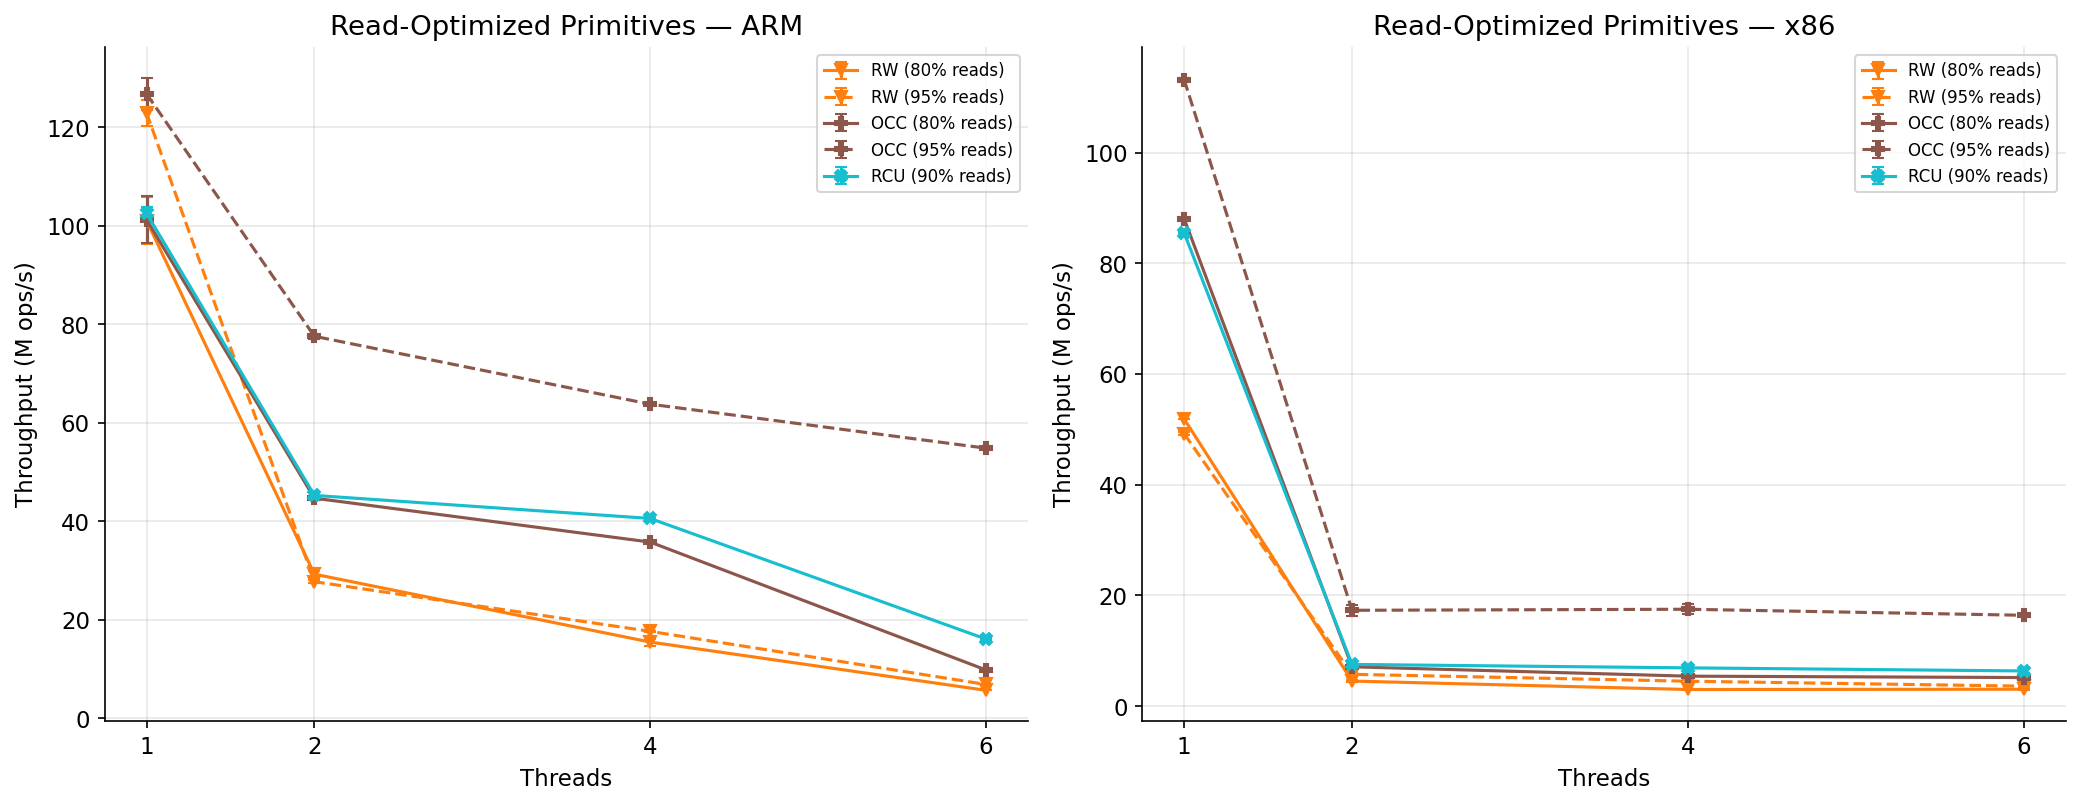

In [35]:
# Combine RW, OCC, and RCU data for read-heavy comparison
rw80 = rw_data[rw_data['read_pct']==80].copy()
rw95 = rw_data[rw_data['read_pct']==95].copy()
rcu = rcu_data.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, plat in zip(axes, ['arm', 'intel']):
    # RW lock under different read %
    for data, label, color, ls, marker in [
        (rw80[rw80['lock']=='rw'], 'RW (80% reads)', '#ff7f0e', '-', 'v'),
        (rw95[rw95['lock']=='rw'], 'RW (95% reads)', '#ff7f0e', '--', 'v'),
        (rw80[rw80['lock']=='occ'], 'OCC (80% reads)', '#8c564b', '-', 'P'),
        (rw95[rw95['lock']=='occ'], 'OCC (95% reads)', '#8c564b', '--', 'P'),
        (rcu, 'RCU (90% reads)', '#17becf', '-', 'X'),
    ]:
        sub = data[data['platform']==plat]
        if sub.empty: continue
        g_sub = sub.groupby('threads')['ops_m'].agg(['mean','std']).reset_index()
        ax.errorbar(g_sub['threads'], g_sub['mean'], yerr=g_sub['std'],
                    label=label, color=color, linestyle=ls, marker=marker,
                    capsize=3, linewidth=1.5)

    ax.set_xlabel('Threads')
    ax.set_ylabel('Throughput (M ops/s)')
    ax.set_title(f'Read-Optimized Primitives \u2014 {PLAT_SHORT[plat]}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([1,2,4,6])

fig.tight_layout()
fig.savefig('plot3_read_optimization.png', bbox_inches='tight')
plt.show()

---
## 7. Spinlock Taxonomy: TAS vs TTAS vs CAS

These three are all test-and-set family spinlocks but differ in bus traffic:  
- **TAS**: Atomic swap on every attempt (high bus traffic)  
- **TTAS**: Spin on cached copy, only atomic when looks free (less bus traffic)  
- **CAS**: Compare-and-swap, similar to TTAS in cache behavior

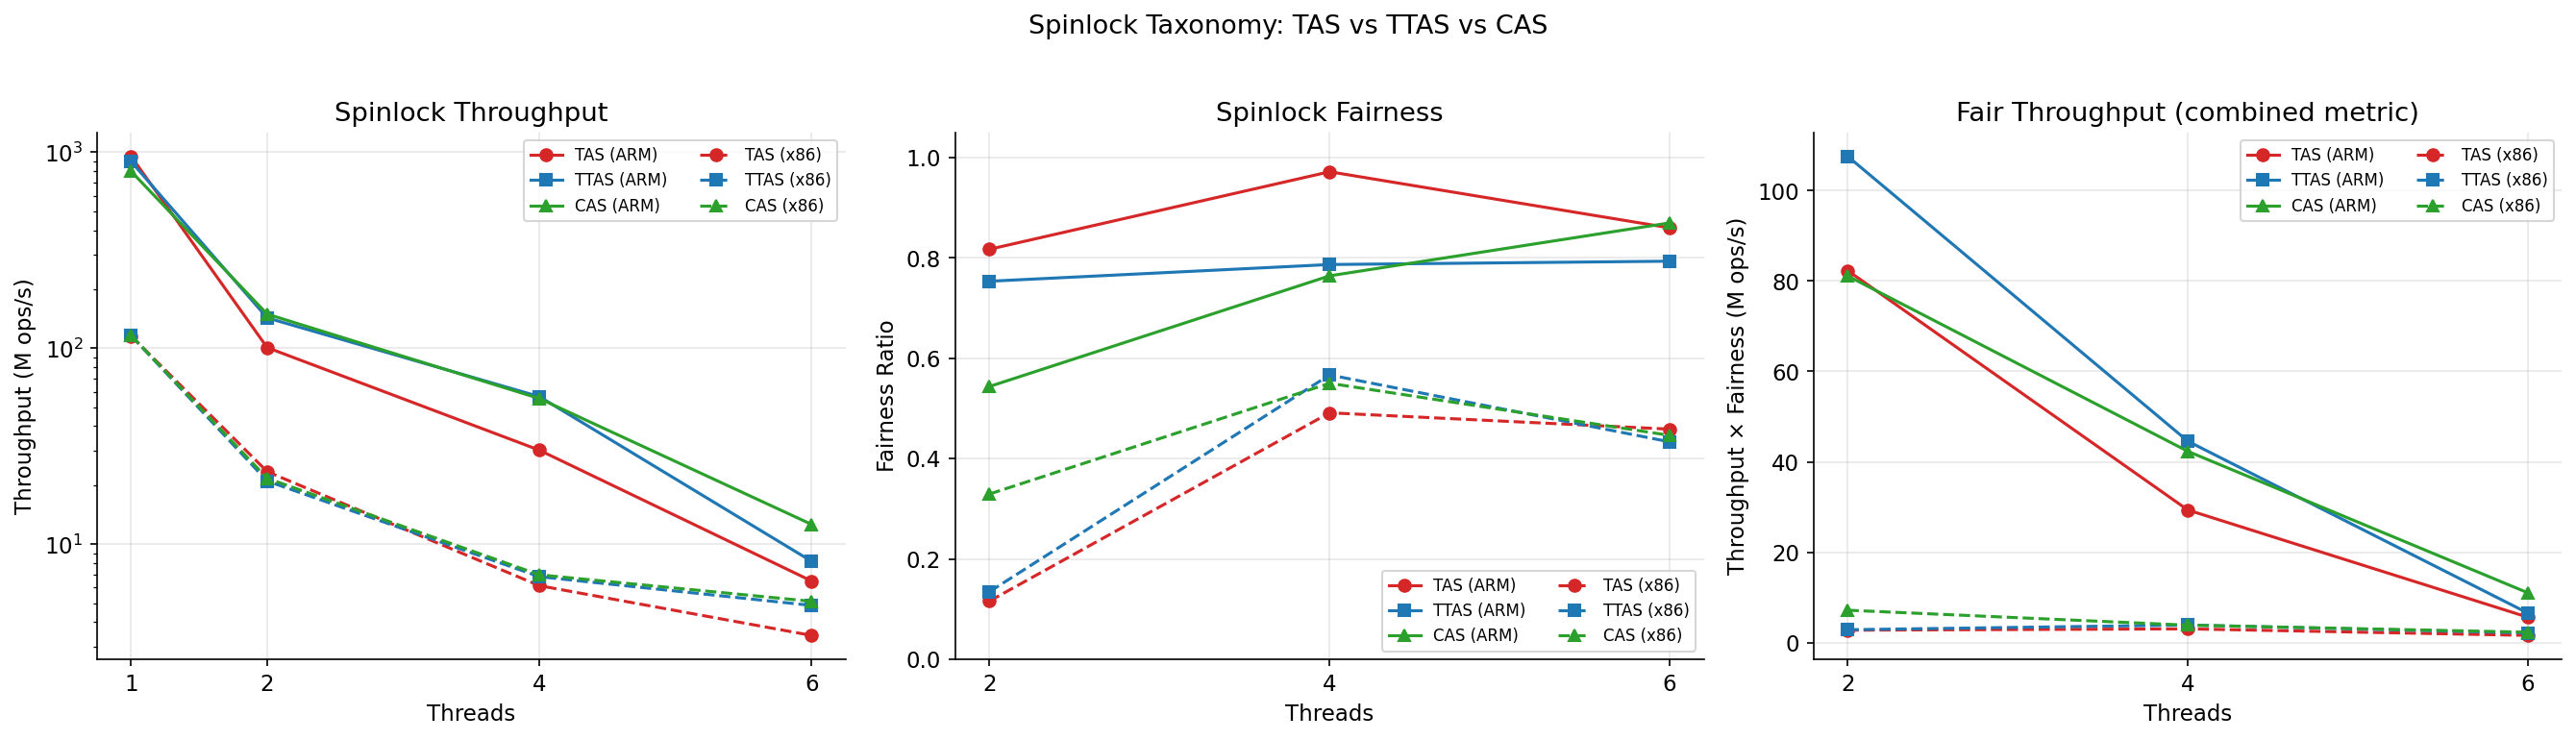

In [36]:
spinlocks = mutex[mutex['lock'].isin(['tas','ttas','cas'])].copy()
g_spin = agg(spinlocks, ['platform','lock','threads'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Throughput comparison
ax = axes[0]
for plat, ls in [('arm', '-'), ('intel', '--')]:
    sub = g_spin[g_spin['platform']==plat]
    for lock in ['tas','ttas','cas']:
        d = sub[sub['lock']==lock].sort_values('threads')
        ax.plot(d['threads'], d['ops_m_mean'], label=f"{LOCK_LABELS[lock]} ({PLAT_SHORT[plat]})",
                color=LOCK_COLORS[lock], linestyle=ls, marker=LOCK_MARKERS[lock], linewidth=1.5)
ax.set_yscale('log')
ax.set_xlabel('Threads')
ax.set_ylabel('Throughput (M ops/s)')
ax.set_title('Spinlock Throughput')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xticks([1,2,4,6])

# Fairness comparison
ax = axes[1]
g_spin_mt = g_spin[g_spin['threads']>1]
for plat, ls in [('arm', '-'), ('intel', '--')]:
    sub = g_spin_mt[g_spin_mt['platform']==plat]
    for lock in ['tas','ttas','cas']:
        d = sub[sub['lock']==lock].sort_values('threads')
        ax.plot(d['threads'], d['fairness_mean'], label=f"{LOCK_LABELS[lock]} ({PLAT_SHORT[plat]})",
                color=LOCK_COLORS[lock], linestyle=ls, marker=LOCK_MARKERS[lock], linewidth=1.5)
ax.set_xlabel('Threads')
ax.set_ylabel('Fairness Ratio')
ax.set_title('Spinlock Fairness')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
ax.set_xticks([2,4,6])

# Throughput-per-unit-fairness (efficiency metric)
ax = axes[2]
g_spin_mt2 = g_spin_mt.copy()
g_spin_mt2['tpf'] = g_spin_mt2['ops_m_mean'] * g_spin_mt2['fairness_mean']
for plat, ls in [('arm', '-'), ('intel', '--')]:
    sub = g_spin_mt2[g_spin_mt2['platform']==plat]
    for lock in ['tas','ttas','cas']:
        d = sub[sub['lock']==lock].sort_values('threads')
        ax.plot(d['threads'], d['tpf'], label=f"{LOCK_LABELS[lock]} ({PLAT_SHORT[plat]})",
                color=LOCK_COLORS[lock], linestyle=ls, marker=LOCK_MARKERS[lock], linewidth=1.5)
ax.set_xlabel('Threads')
ax.set_ylabel('Throughput \u00d7 Fairness (M ops/s)')
ax.set_title('Fair Throughput (combined metric)')
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xticks([2,4,6])

fig.suptitle('Spinlock Taxonomy: TAS vs TTAS vs CAS', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig('plot10_spinlock_taxonomy.png', bbox_inches='tight')
plt.show()

---
## 8. Platform Comparison — ARM/Intel Throughput Ratio

Ratio > 1 means ARM wins. The dashed line at 1.0 = parity.

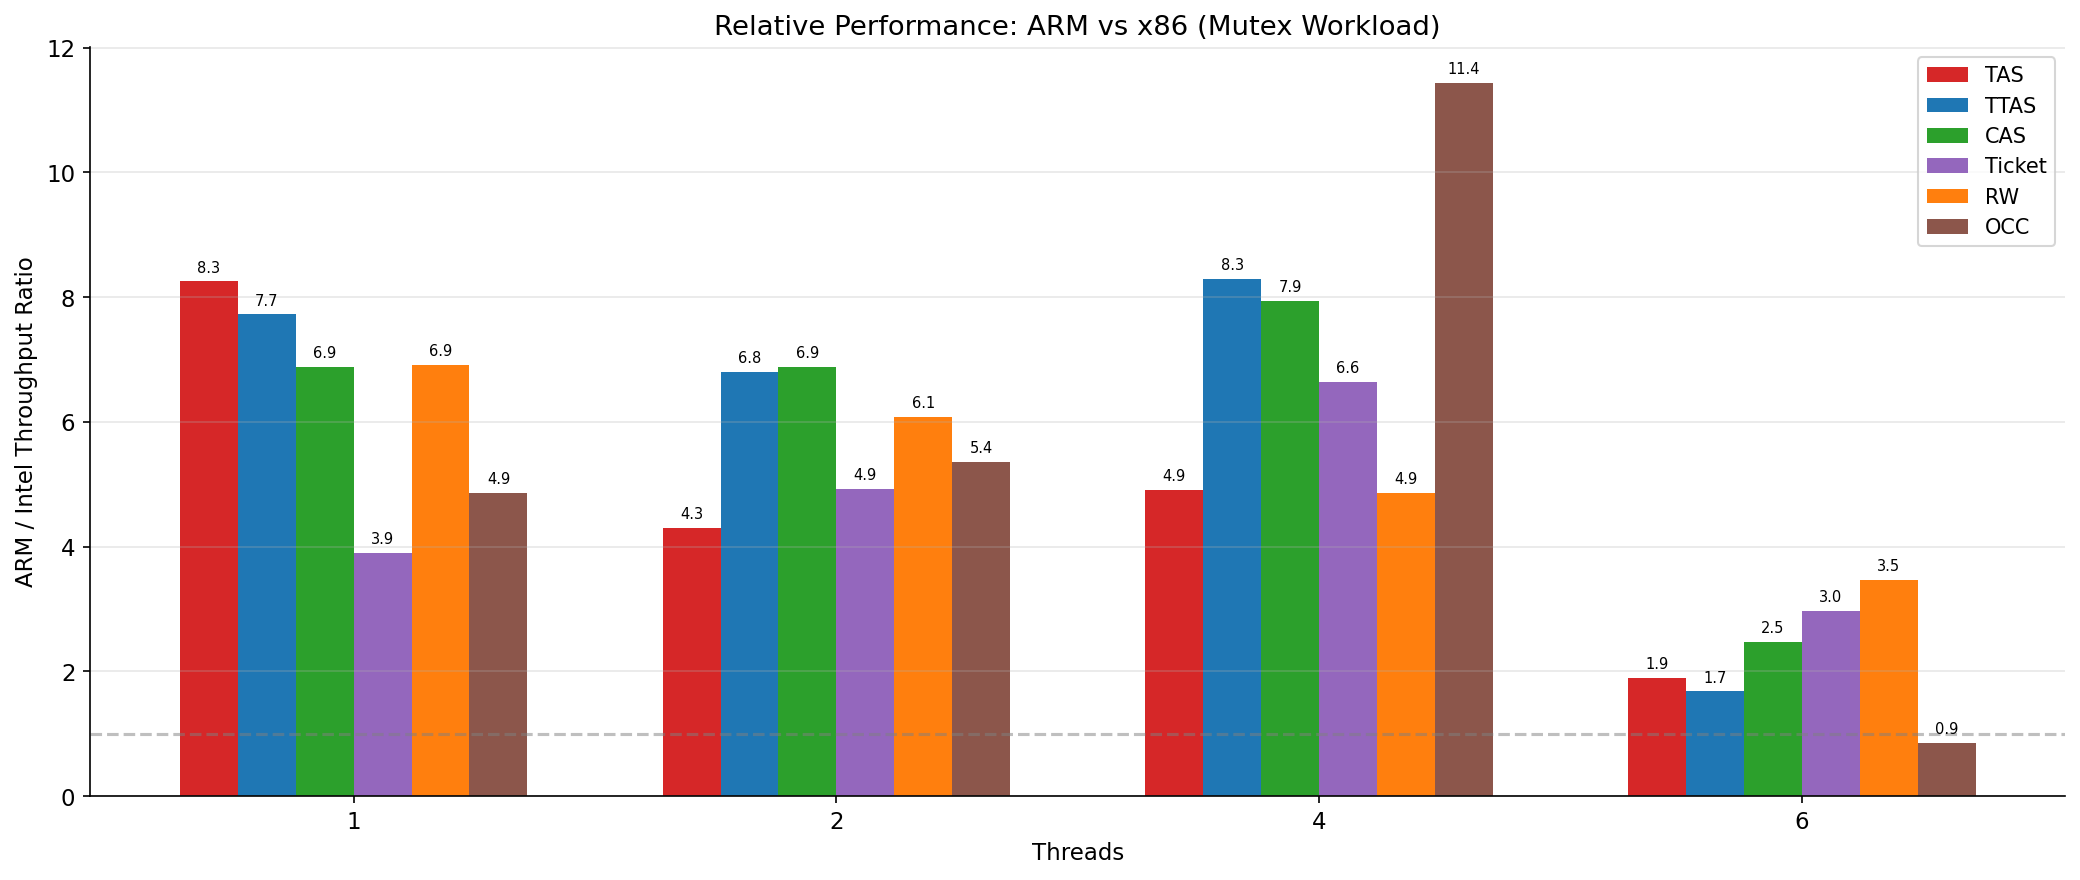

In [37]:
g_ratio = agg(mutex, ['platform', 'lock', 'threads'])
arm_g = g_ratio[g_ratio['platform']=='arm'].set_index(['lock','threads'])['ops_m_mean']
x86_g = g_ratio[g_ratio['platform']=='intel'].set_index(['lock','threads'])['ops_m_mean']
ratio = (arm_g / x86_g).reset_index()
ratio.columns = ['lock', 'threads', 'ratio']

threads_list = sorted(ratio['threads'].unique())
n_locks = len(LOCK_ORDER)
x = np.arange(len(threads_list))
width = 0.12

fig, ax = plt.subplots(figsize=(14, 6))
for i, lock in enumerate(LOCK_ORDER):
    d = ratio[ratio['lock']==lock].set_index('threads')['ratio']
    vals = [d.get(t, 0) for t in threads_list]
    offset = (i - n_locks/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=LOCK_LABELS[lock], color=LOCK_COLORS[lock])
    # Annotate values
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=7)

ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Threads')
ax.set_ylabel('ARM / Intel Throughput Ratio')
ax.set_title('Relative Performance: ARM vs x86 (Mutex Workload)')
ax.set_xticks(x)
ax.set_xticklabels(threads_list)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig('plot5_arm_intel_ratio.png', bbox_inches='tight')
plt.show()

---
## 9. Critical Section Sensitivity — TTAS 4T

How does throughput change as we increase the work done inside the critical section?

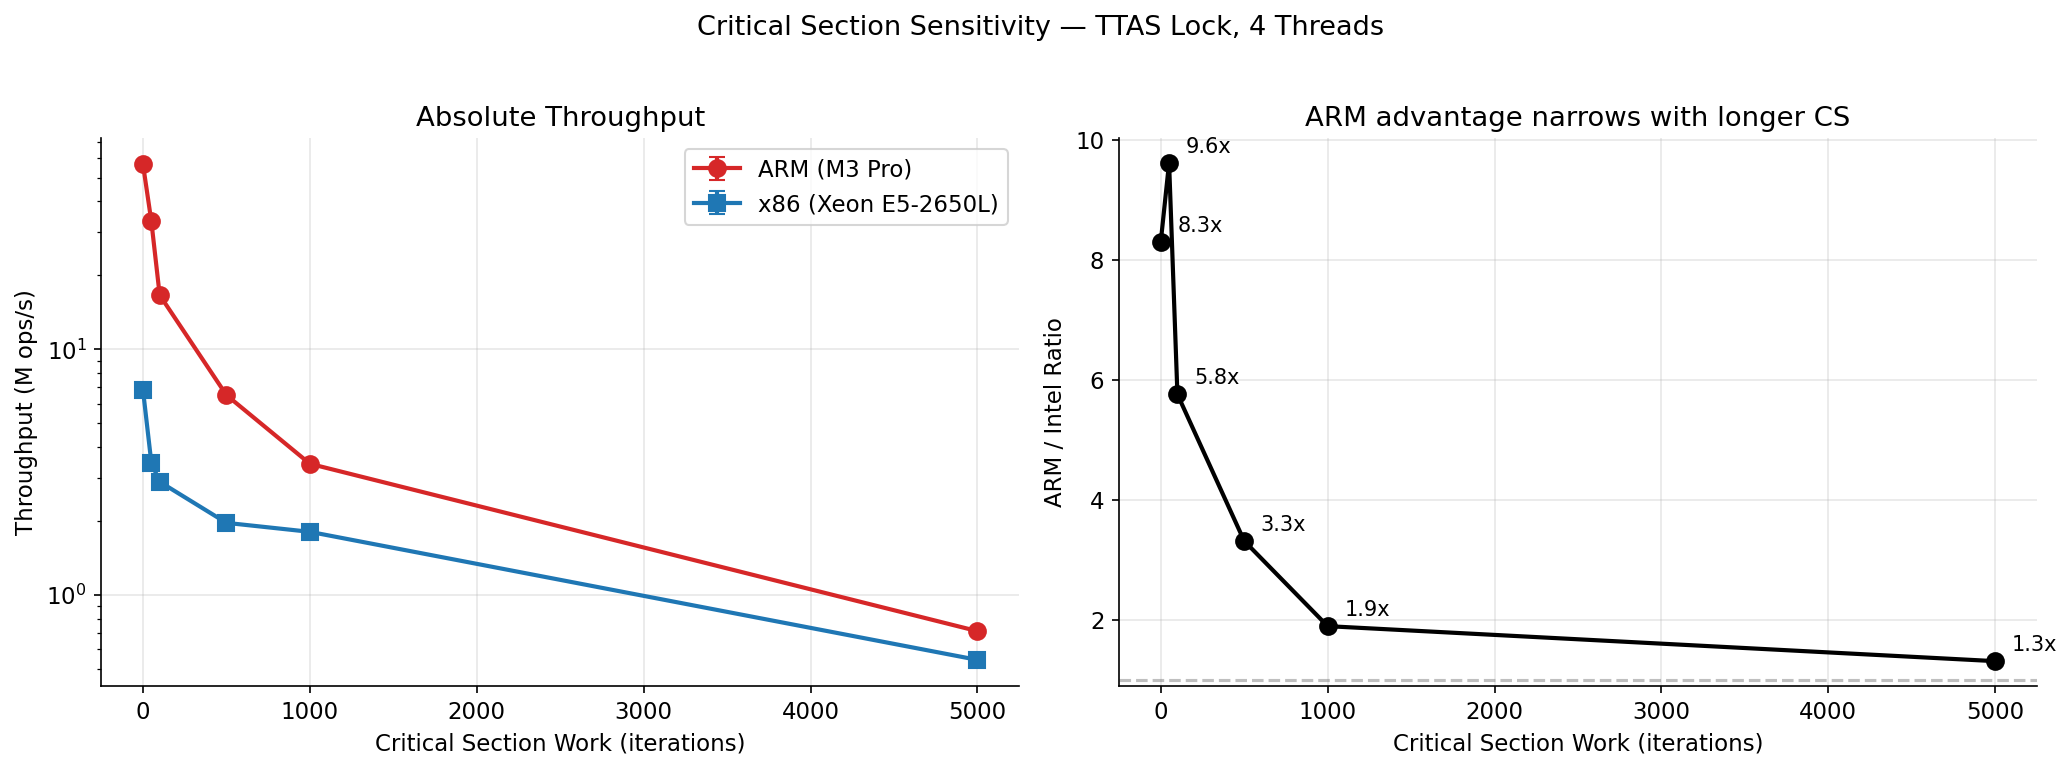

In [38]:
g4 = agg(cs_sweep, ['platform', 'cs_work'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute throughput
ax = axes[0]
for plat, label, color, marker in [('arm', 'ARM (M3 Pro)', '#d62728', 'o'),
                                    ('intel', 'x86 (Xeon E5-2650L)', '#1f77b4', 's')]:
    d = g4[g4['platform']==plat].sort_values('cs_work')
    ax.errorbar(d['cs_work'], d['ops_m_mean'], yerr=d['ops_m_std'],
                label=label, color=color, marker=marker, capsize=4, linewidth=2, markersize=8)
ax.set_yscale('log')
ax.set_xlabel('Critical Section Work (iterations)')
ax.set_ylabel('Throughput (M ops/s)')
ax.set_title('Absolute Throughput')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# ARM/Intel ratio vs cs_work
ax = axes[1]
arm_cs = g4[g4['platform']=='arm'].set_index('cs_work')['ops_m_mean']
int_cs = g4[g4['platform']=='intel'].set_index('cs_work')['ops_m_mean']
cs_ratio = (arm_cs / int_cs).reset_index()
cs_ratio.columns = ['cs_work', 'ratio']
ax.plot(cs_ratio['cs_work'], cs_ratio['ratio'], 'ko-', linewidth=2, markersize=8)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Critical Section Work (iterations)')
ax.set_ylabel('ARM / Intel Ratio')
ax.set_title('ARM advantage narrows with longer CS')
ax.grid(True, alpha=0.3)
for _, row in cs_ratio.iterrows():
    ax.annotate(f"{row['ratio']:.1f}x", (row['cs_work'], row['ratio']),
               textcoords='offset points', xytext=(8, 5), fontsize=10)

fig.suptitle('Critical Section Sensitivity \u2014 TTAS Lock, 4 Threads', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig('plot4_cs_sensitivity.png', bbox_inches='tight')
plt.show()

---
## 10. Variance Heatmap (CV%)

Run-to-run coefficient of variation. Low values = reproducible measurements.

/var/folders/bx/qxvsk6k93_g7w59yp71ff7tw0000gn/T/ipykernel_24752/291154853.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


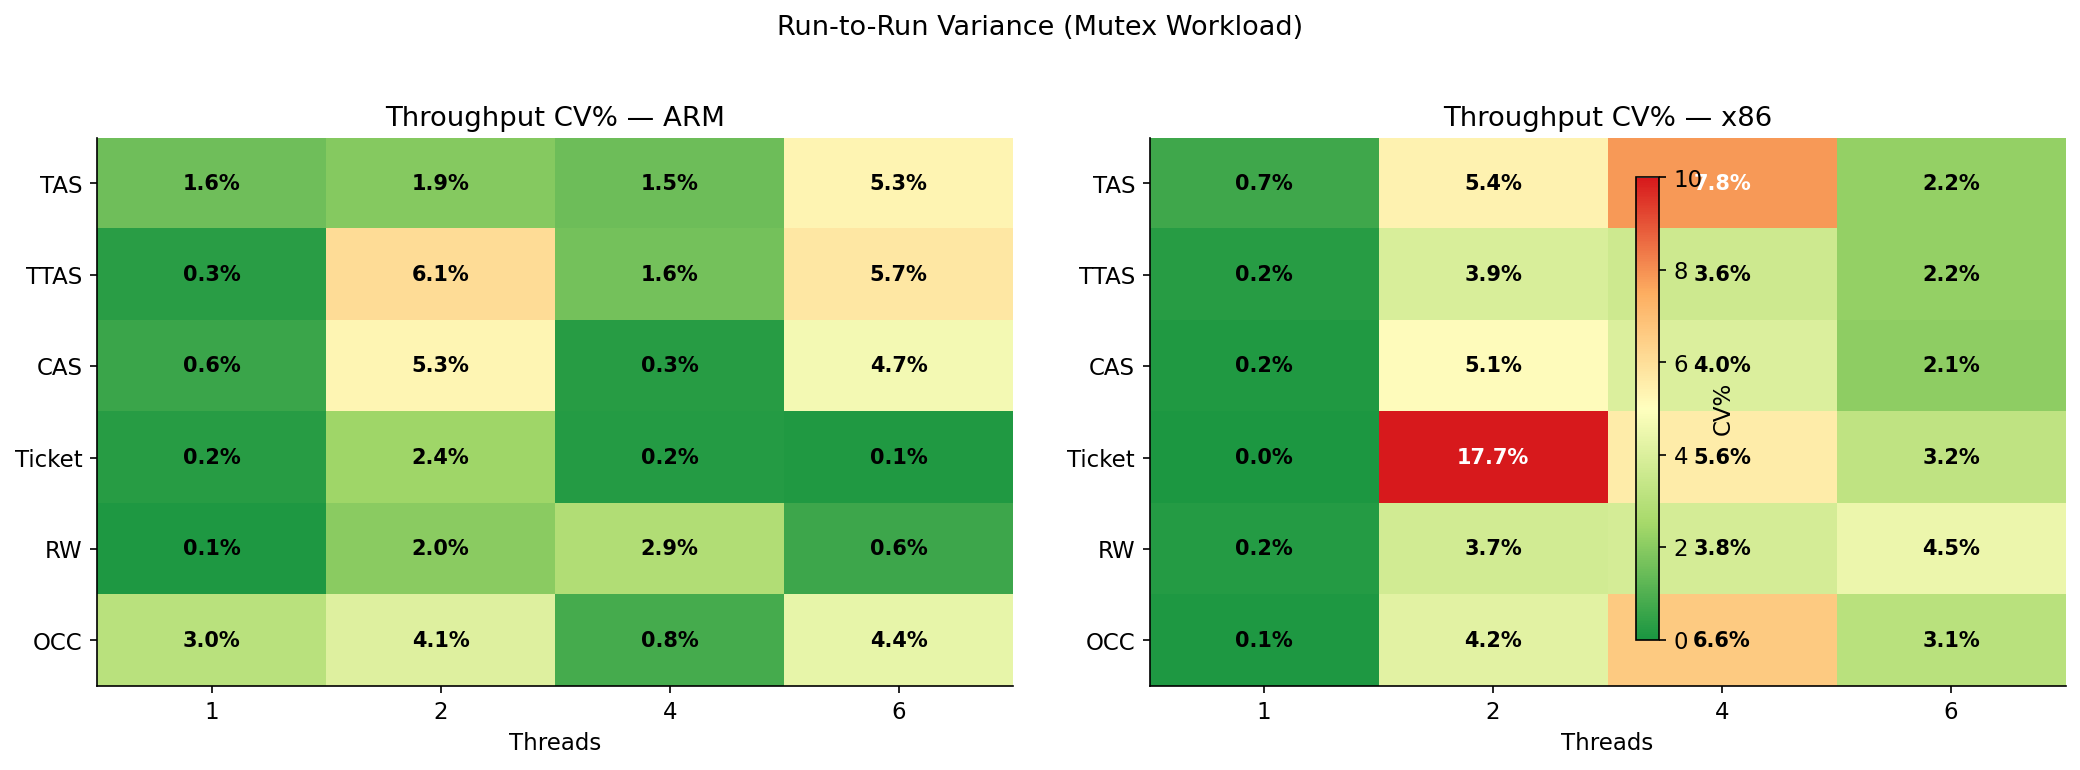

In [39]:
mutex_cv = mutex.groupby(['platform', 'lock', 'threads'])['ops_m'].agg(['mean', 'std']).reset_index()
mutex_cv['cv_pct'] = (mutex_cv['std'] / mutex_cv['mean']) * 100

cmap_cv = mcolors.LinearSegmentedColormap.from_list('cv',
    ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, plat in zip(axes, ['arm', 'intel']):
    sub = mutex_cv[mutex_cv['platform'] == plat]
    pivot = sub.pivot(index='lock', columns='threads', values='cv_pct')
    pivot = pivot.reindex(LOCK_ORDER)
    pivot.index = [LOCK_LABELS.get(l, l) for l in pivot.index]

    im = ax.imshow(pivot.values, cmap=cmap_cv, vmin=0, vmax=10, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('Threads')
    ax.set_title(f'Throughput CV% \u2014 {PLAT_SHORT[plat]}')

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                        fontweight='bold', fontsize=10,
                        color='white' if val > 7 else 'black')

fig.colorbar(im, ax=axes, label='CV%', shrink=0.8)
fig.suptitle('Run-to-Run Variance (Mutex Workload)', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig('plot6_variance_heatmap.png', bbox_inches='tight')
plt.show()

---
## 11. Lock Ranking: Normalized Radar Chart

Compare locks across multiple dimensions at 4 threads.

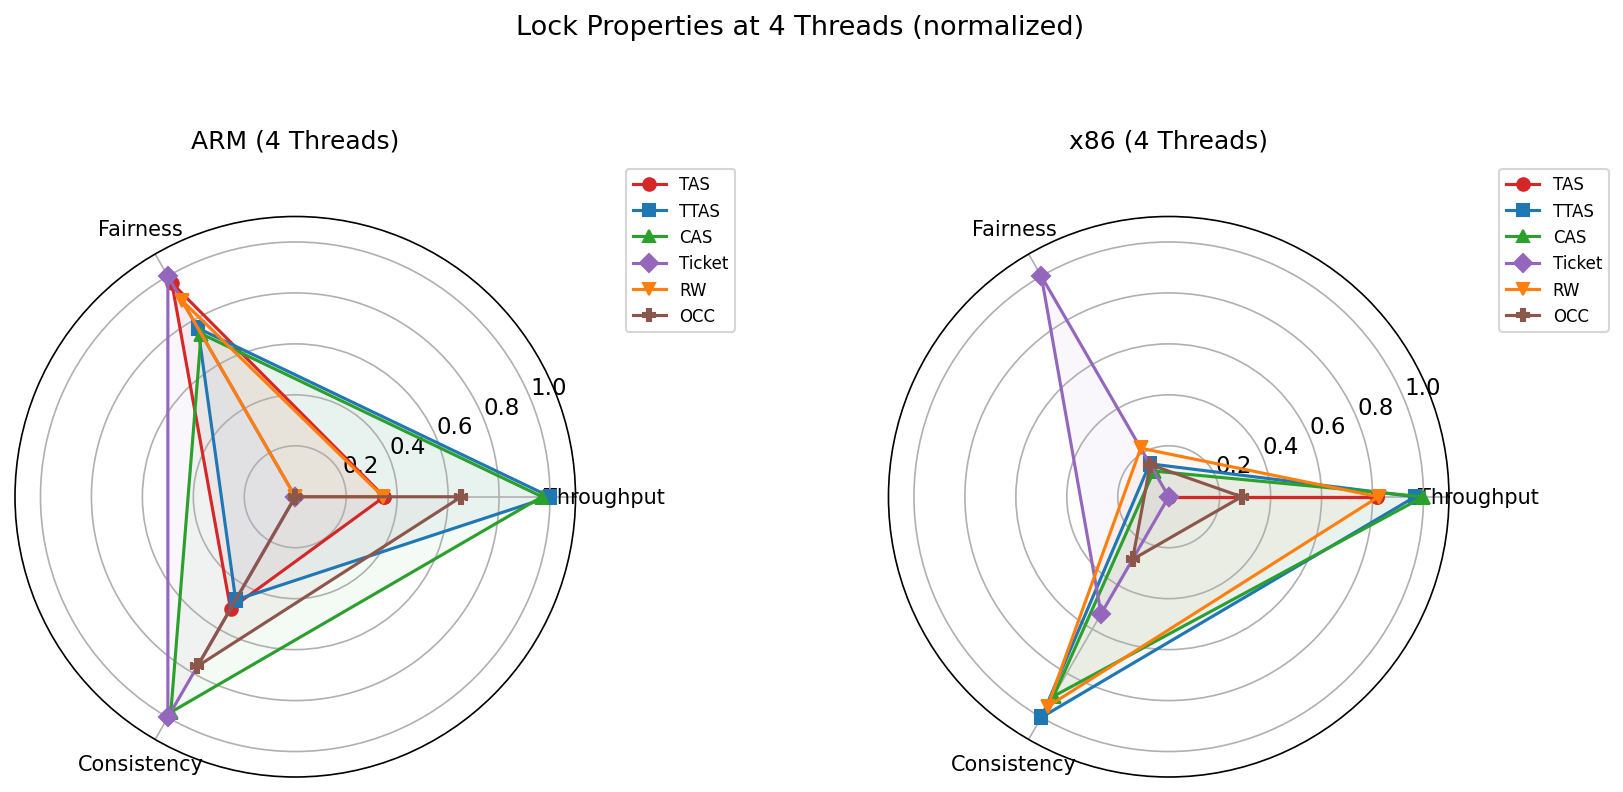

In [40]:
from matplotlib.patches import FancyBboxPatch

# Compute metrics at 4 threads
g_4t = mutex[mutex['threads']==4].groupby(['platform','lock']).agg(
    throughput=('ops_m','mean'),
    fairness=('fairness_ratio','mean'),
    consistency=('ops_m', lambda x: 1 - x.std()/x.mean()),  # 1-CV
).reset_index()

# Normalize each metric to [0,1] within each platform
for plat in ['arm','intel']:
    mask = g_4t['platform']==plat
    for col in ['throughput','fairness','consistency']:
        vals = g_4t.loc[mask, col]
        g_4t.loc[mask, col+'_norm'] = (vals - vals.min()) / (vals.max() - vals.min() + 1e-10)

metrics = ['throughput_norm', 'fairness_norm', 'consistency_norm']
metric_labels = ['Throughput', 'Fairness', 'Consistency']
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw=dict(polar=True))
for ax, plat in zip(axes, ['arm', 'intel']):
    for lock in LOCK_ORDER:
        row = g_4t[(g_4t['platform']==plat) & (g_4t['lock']==lock)]
        if row.empty: continue
        values = [row[m].values[0] for m in metrics]
        values += values[:1]
        ax.plot(angles, values, label=LOCK_LABELS[lock], color=LOCK_COLORS[lock],
                linewidth=1.5, marker=LOCK_MARKERS[lock], markersize=6)
        ax.fill(angles, values, alpha=0.05, color=LOCK_COLORS[lock])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metric_labels, fontsize=10)
    ax.set_title(f'{PLAT_SHORT[plat]} (4 Threads)', y=1.1, fontsize=12)
    ax.legend(fontsize=8, loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.set_ylim(0, 1.1)

fig.suptitle('Lock Properties at 4 Threads (normalized)', fontsize=13, y=1.05)
fig.tight_layout()
fig.savefig('plot11_radar_chart.png', bbox_inches='tight')
plt.show()

---
## 12. Platform Crossover: Where Does ARM Lose?

For each lock and workload, find the thread count where ARM/Intel ratio approaches or drops below 1.

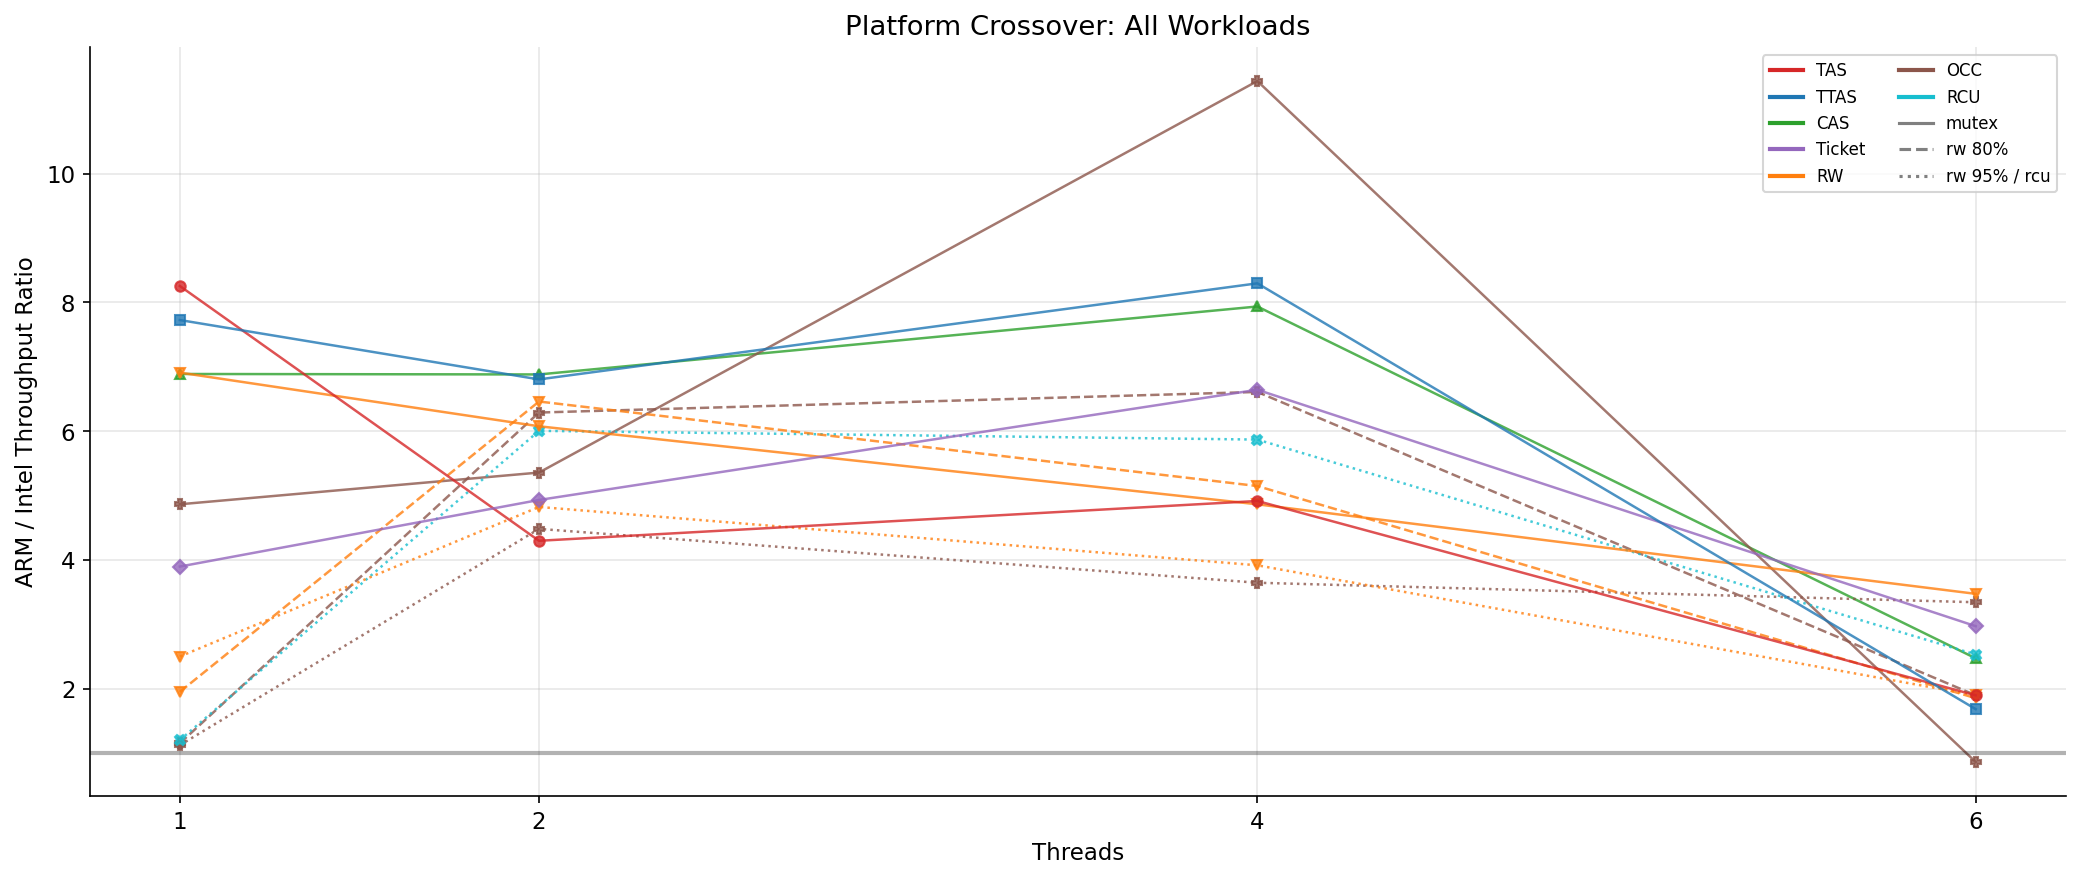


Configs where Intel beats ARM at 6 threads:
  occ_mutex_r100: ratio = 0.86 (Intel is 1.2x faster)


In [41]:
# Compute ratios across all workloads
all_data = df[df['cs_work']==0].copy()  # exclude cs_sweep
all_data['config'] = all_data['lock'] + '_' + all_data['workload'] + '_r' + all_data['read_pct'].astype(int).astype(str)

g_all = all_data.groupby(['platform','config','threads'])['ops_m'].mean().reset_index()
arm_all = g_all[g_all['platform']=='arm'].set_index(['config','threads'])['ops_m']
int_all = g_all[g_all['platform']=='intel'].set_index(['config','threads'])['ops_m']
ratio_all = (arm_all / int_all).reset_index()
ratio_all.columns = ['config', 'threads', 'ratio']

fig, ax = plt.subplots(figsize=(14, 6))

# Color by lock
for config in sorted(ratio_all['config'].unique()):
    d = ratio_all[ratio_all['config']==config].sort_values('threads')
    lock = config.split('_')[0]
    workload = '_'.join(config.split('_')[1:])
    ls = '-' if 'mutex' in workload else ('--' if '80' in workload else ':')
    ax.plot(d['threads'], d['ratio'], color=LOCK_COLORS.get(lock,'gray'),
            linestyle=ls, marker=LOCK_MARKERS.get(lock,'o'), linewidth=1.2,
            markersize=5, alpha=0.8)

ax.axhline(y=1, color='black', linestyle='-', linewidth=2, alpha=0.3, label='Parity')
ax.set_xlabel('Threads')
ax.set_ylabel('ARM / Intel Throughput Ratio')
ax.set_title('Platform Crossover: All Workloads')
ax.set_xticks([1,2,4,6])
ax.grid(True, alpha=0.3)

# Custom legend
lock_handles = [Line2D([0],[0], color=LOCK_COLORS[l], linewidth=2, label=LOCK_LABELS[l])
                for l in LOCK_ORDER + ['rcu']]
wl_handles = [Line2D([0],[0], color='gray', linestyle='-', label='mutex'),
              Line2D([0],[0], color='gray', linestyle='--', label='rw 80%'),
              Line2D([0],[0], color='gray', linestyle=':', label='rw 95% / rcu')]
ax.legend(handles=lock_handles + wl_handles, fontsize=8, ncol=2, loc='upper right')

fig.tight_layout()
fig.savefig('plot12_platform_crossover.png', bbox_inches='tight')
plt.show()

# Find configs where ARM loses at 6T
arm_loses = ratio_all[(ratio_all['threads']==6) & (ratio_all['ratio'] < 1.0)]
print("\nConfigs where Intel beats ARM at 6 threads:")
for _, row in arm_loses.iterrows():
    print(f"  {row['config']}: ratio = {row['ratio']:.2f} (Intel is {1/row['ratio']:.1f}x faster)")

---
## 13. Contention Drop Table

How much throughput is lost going from 1 thread to N threads (contention penalty).

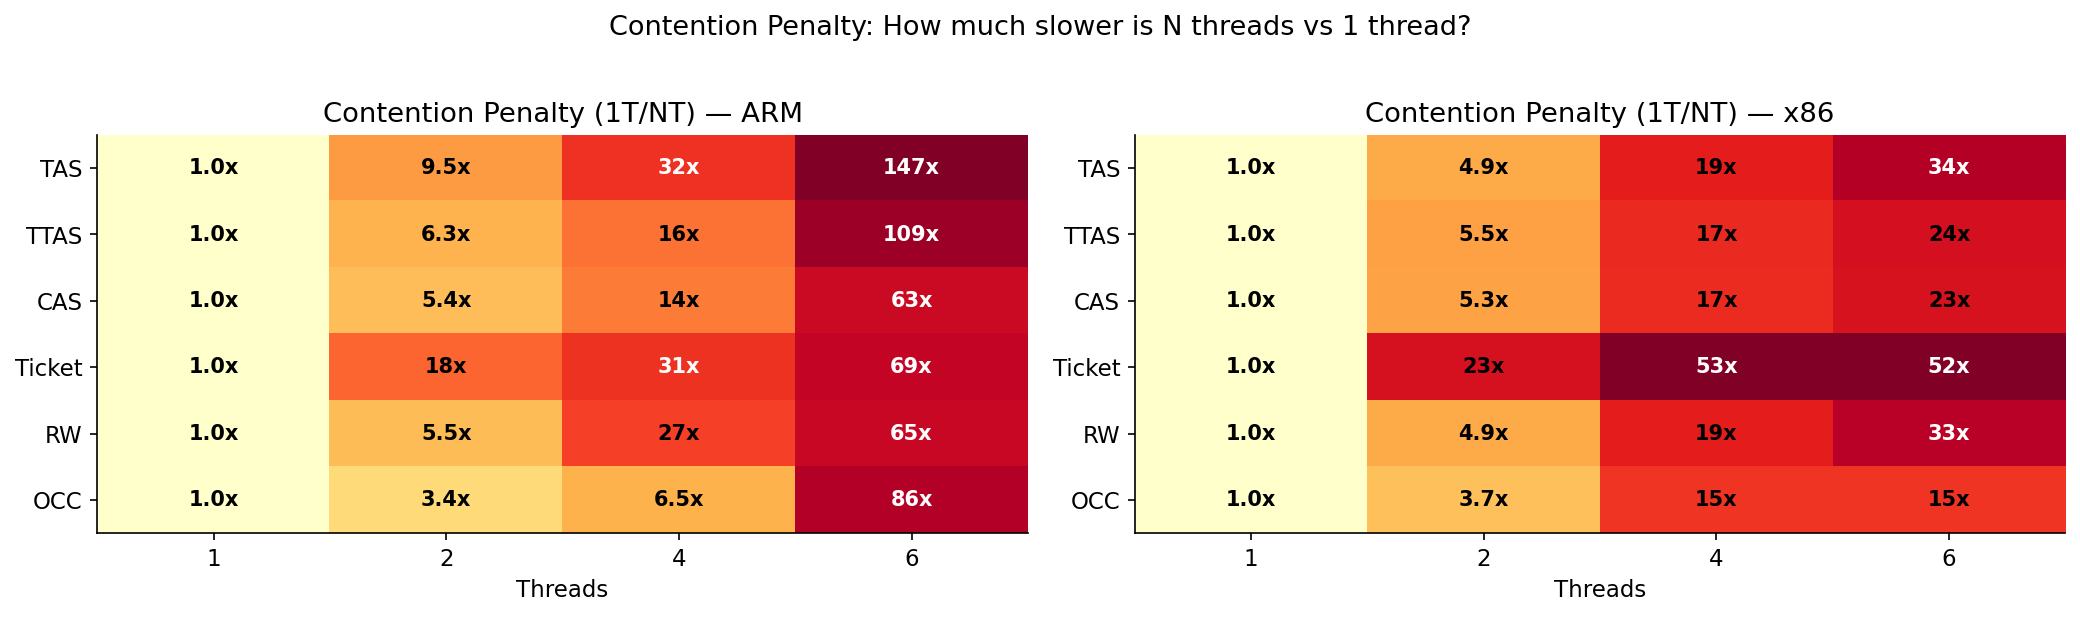

In [42]:
g_drop = agg(mutex, ['platform','lock','threads'])
base = g_drop[g_drop['threads']==1][['platform','lock','ops_m_mean']].rename(
    columns={'ops_m_mean':'t1_ops'})
g_drop = g_drop.merge(base, on=['platform','lock'])
g_drop['penalty'] = g_drop['t1_ops'] / g_drop['ops_m_mean']

# Format as table
pivot_arm = g_drop[g_drop['platform']=='arm'].pivot(
    index='lock', columns='threads', values='penalty').reindex(LOCK_ORDER)
pivot_arm.index = [LOCK_LABELS.get(l,l) for l in pivot_arm.index]
pivot_int = g_drop[g_drop['platform']=='intel'].pivot(
    index='lock', columns='threads', values='penalty').reindex(LOCK_ORDER)
pivot_int.index = [LOCK_LABELS.get(l,l) for l in pivot_int.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, pivot, plat in [(axes[0], pivot_arm, 'ARM'), (axes[1], pivot_int, 'x86')]:
    im = ax.imshow(np.log10(pivot.values), cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('Threads')
    ax.set_title(f'Contention Penalty (1T/NT) \u2014 {plat}')
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                txt = f'{val:.0f}x' if val >= 10 else f'{val:.1f}x'
                ax.text(j, i, txt, ha='center', va='center',
                        fontweight='bold', fontsize=10,
                        color='white' if val > 30 else 'black')

fig.suptitle('Contention Penalty: How much slower is N threads vs 1 thread?', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig('plot13_contention_penalty.png', bbox_inches='tight')
plt.show()

---
## 14. RCU vs Reader-Writer Lock

RCU uses a fundamentally different approach: readers are wait-free, writers defer cleanup.  
Compare with RW lock under 80% reads and OCC at 95% reads.

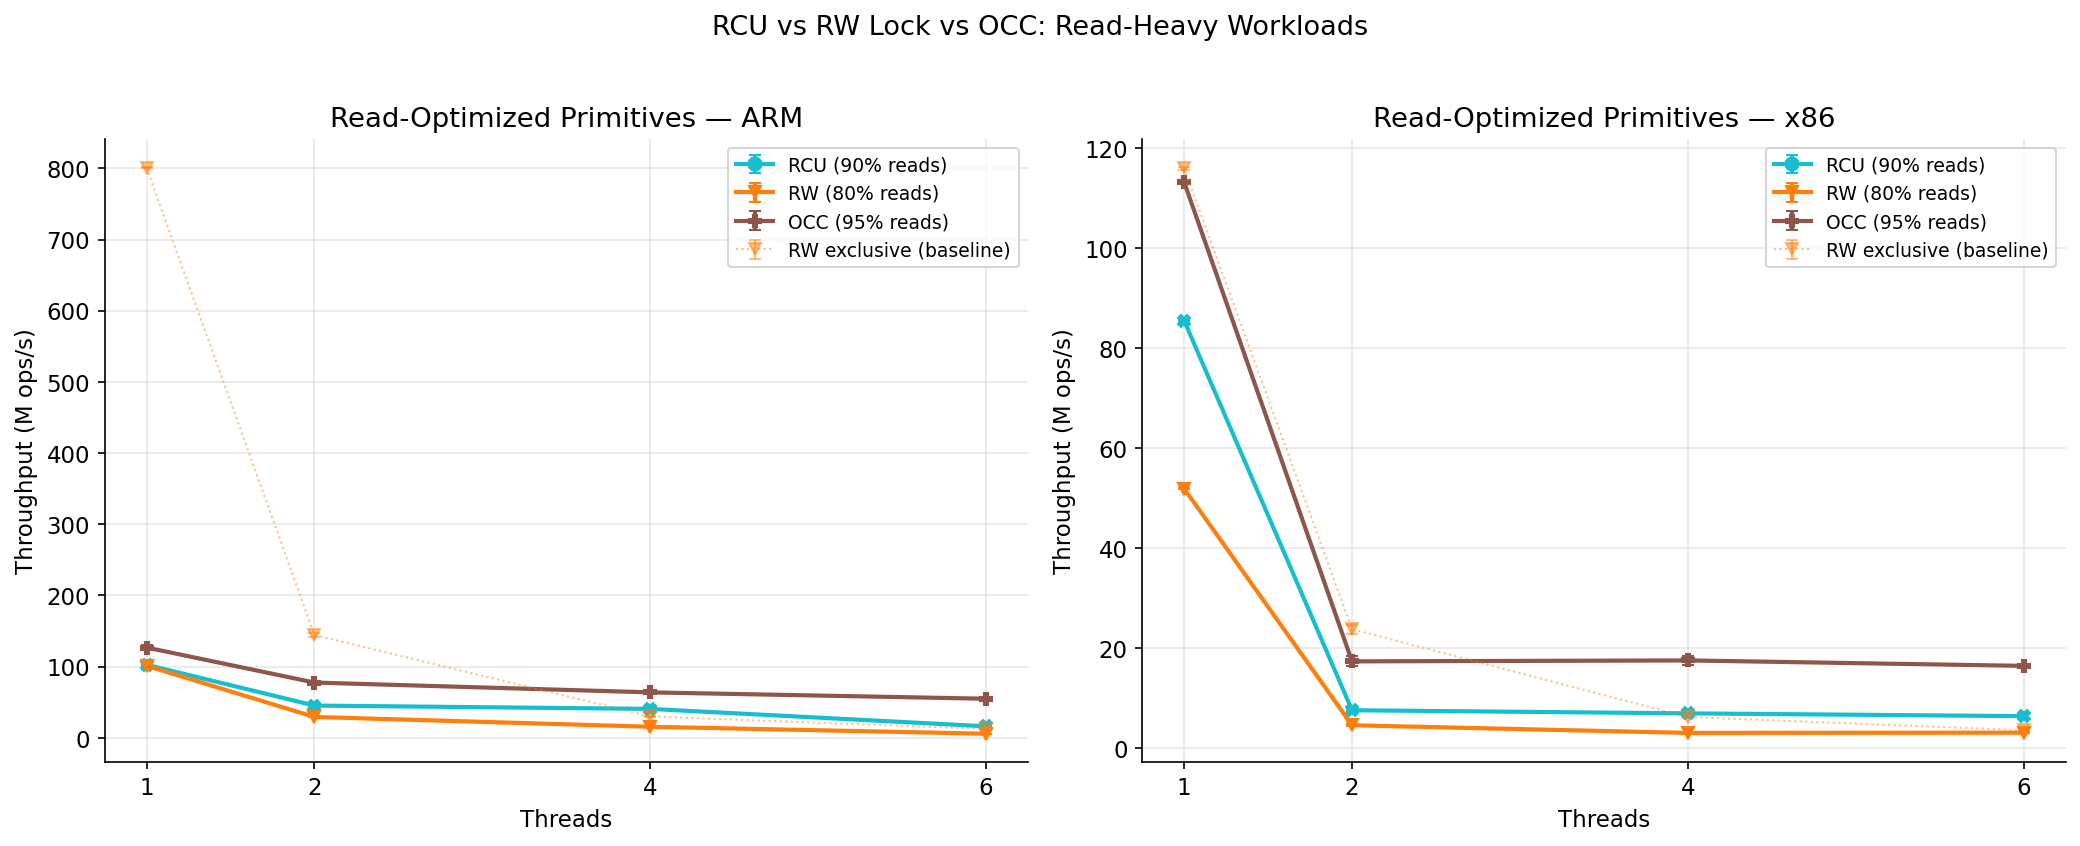


ARM RCU scaling: 1T=102.5  2T=45.2  4T=40.6  6T=16.1
  6T/1T efficiency: 0.157

x86 RCU scaling: 1T=85.5  2T=7.5  4T=6.9  6T=6.4
  6T/1T efficiency: 0.074


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, plat in zip(axes, ['arm', 'intel']):
    # RCU (90% reads)
    rcu_sub = rcu_data[rcu_data['platform']==plat].groupby('threads')['ops_m'].agg(['mean','std']).reset_index()
    ax.errorbar(rcu_sub['threads'], rcu_sub['mean'], yerr=rcu_sub['std'],
                label='RCU (90% reads)', color='#17becf', marker='X', linewidth=2, capsize=3)

    # RW lock rw 80%
    rw80_sub = rw_data[(rw_data['platform']==plat) & (rw_data['lock']=='rw') & (rw_data['read_pct']==80)]
    g_rw80 = rw80_sub.groupby('threads')['ops_m'].agg(['mean','std']).reset_index()
    ax.errorbar(g_rw80['threads'], g_rw80['mean'], yerr=g_rw80['std'],
                label='RW (80% reads)', color='#ff7f0e', marker='v', linewidth=2, capsize=3)

    # OCC rw 95%
    occ95_sub = rw_data[(rw_data['platform']==plat) & (rw_data['lock']=='occ') & (rw_data['read_pct']==95)]
    g_occ95 = occ95_sub.groupby('threads')['ops_m'].agg(['mean','std']).reset_index()
    ax.errorbar(g_occ95['threads'], g_occ95['mean'], yerr=g_occ95['std'],
                label='OCC (95% reads)', color='#8c564b', marker='P', linewidth=2, capsize=3)

    # RW mutex (exclusive, for reference)
    rw_excl = mutex[(mutex['platform']==plat) & (mutex['lock']=='rw')]
    g_excl = rw_excl.groupby('threads')['ops_m'].agg(['mean','std']).reset_index()
    ax.errorbar(g_excl['threads'], g_excl['mean'], yerr=g_excl['std'],
                label='RW exclusive (baseline)', color='#ff7f0e', marker='v',
                linewidth=1, capsize=3, linestyle=':', alpha=0.5)

    ax.set_xlabel('Threads')
    ax.set_ylabel('Throughput (M ops/s)')
    ax.set_title(f'Read-Optimized Primitives \u2014 {PLAT_SHORT[plat]}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xticks([1,2,4,6])

fig.suptitle('RCU vs RW Lock vs OCC: Read-Heavy Workloads', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig('plot14_rcu_comparison.png', bbox_inches='tight')
plt.show()

# Print scaling comparison
for plat in ['arm','intel']:
    rcu_1t = rcu_data[rcu_data['platform']==plat].groupby('threads')['ops_m'].mean()
    print(f"\n{PLAT_SHORT[plat]} RCU scaling: 1T={rcu_1t.get(1,0):.1f}  2T={rcu_1t.get(2,0):.1f}  4T={rcu_1t.get(4,0):.1f}  6T={rcu_1t.get(6,0):.1f}")
    print(f"  6T/1T efficiency: {rcu_1t.get(6,0)/rcu_1t.get(1,0):.3f}")

---
## 15. Memory Ordering Effect: ARM vs x86 at 1 Thread

At 1 thread there is no contention. The difference between platforms is purely  
microarchitectural: clock speed, pipeline depth, and memory ordering cost.  
ARM uses acquire/release semantics (cheap), x86 uses TSO (store buffer drain on atomic ops).

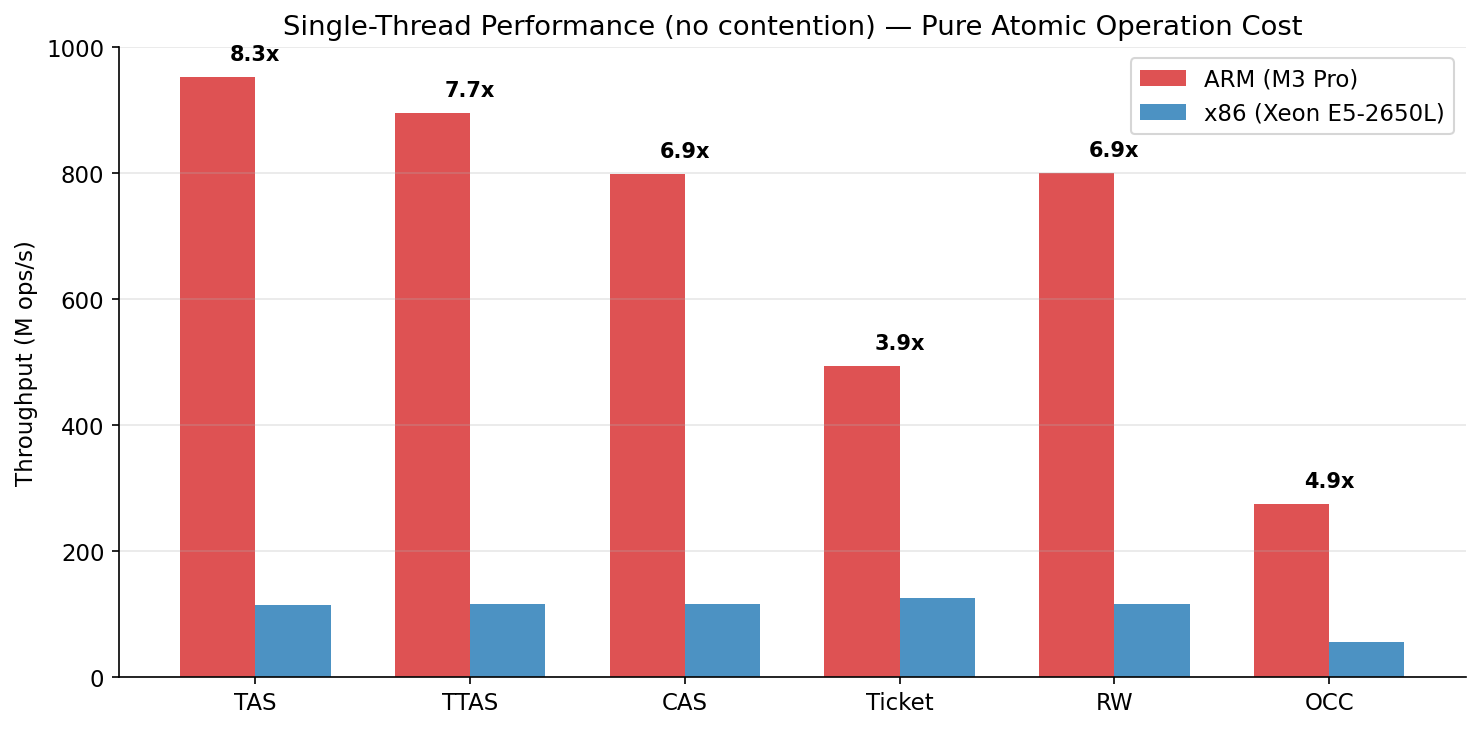


1-thread throughput (M ops/s):
platform    arm  intel  ratio
TAS       953.0  115.5    8.3
TTAS      896.2  116.0    7.7
CAS       799.2  116.1    6.9
Ticket    493.9  126.8    3.9
RW        800.9  115.9    6.9
OCC       274.5   56.4    4.9


In [44]:
t1 = mutex[mutex['threads']==1].groupby(['platform','lock'])['ops_m'].mean().reset_index()
t1_pivot = t1.pivot(index='lock', columns='platform', values='ops_m').reindex(LOCK_ORDER)
t1_pivot.index = [LOCK_LABELS.get(l,l) for l in t1_pivot.index]
t1_pivot['ratio'] = t1_pivot['arm'] / t1_pivot['intel']

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(t1_pivot))
w = 0.35
bars1 = ax.bar(x - w/2, t1_pivot['arm'], w, label='ARM (M3 Pro)', color='#d62728', alpha=0.8)
bars2 = ax.bar(x + w/2, t1_pivot['intel'], w, label='x86 (Xeon E5-2650L)', color='#1f77b4', alpha=0.8)

# Annotate ratios
for i, (_, row) in enumerate(t1_pivot.iterrows()):
    ax.annotate(f"{row['ratio']:.1f}x", (i, max(row['arm'], row['intel'])),
               textcoords='offset points', xytext=(0, 8), ha='center',
               fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(t1_pivot.index)
ax.set_ylabel('Throughput (M ops/s)')
ax.set_title('Single-Thread Performance (no contention) — Pure Atomic Operation Cost')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig('plot15_single_thread.png', bbox_inches='tight')
plt.show()

print("\n1-thread throughput (M ops/s):")
print(t1_pivot[['arm','intel','ratio']].round(1).to_string())

---
## 16. Summary Statistics Table

In [45]:
summary = mutex.groupby(['platform', 'lock', 'threads']).agg(
    mean_ops_m=('ops_m', 'mean'),
    std_ops_m=('ops_m', 'std'),
    mean_fairness=('fairness_ratio', 'mean'),
    std_fairness=('fairness_ratio', 'std')
).reset_index()
summary['cv_pct'] = (summary['std_ops_m'] / summary['mean_ops_m'] * 100).round(1)
summary['mean_ops_m'] = summary['mean_ops_m'].round(1)
summary['std_ops_m'] = summary['std_ops_m'].round(2)
summary['mean_fairness'] = summary['mean_fairness'].round(3)
print("Mutex workload summary (cs_work=0 only):")
display(summary.sort_values(['platform', 'lock', 'threads']))

Mutex workload summary (cs_work=0 only):


,platform,lock,threads,mean_ops_m,std_ops_m,mean_fairness,std_fairness,cv_pct
0,arm,cas,1,799.2,4.94,1.000,0.000000,0.6
1,arm,cas,2,149.3,7.89,0.544,0.205961,5.3
2,arm,cas,4,55.4,0.14,0.764,0.115195,0.3
3,arm,cas,6,12.6,0.59,0.870,0.023953,4.7
4,arm,occ,1,274.5,8.37,1.000,0.000000,3.0
5,arm,occ,2,81.7,3.33,0.489,0.282668,4.1
6,arm,occ,4,42.5,0.35,0.098,0.076519,0.8
7,arm,occ,6,3.2,0.14,0.899,0.017542,4.4
8,arm,rw,1,800.9,0.86,1.000,0.000000,0.1
9,arm,rw,2,144.4,2.91,0.753,0.118175,2.0
